In [3]:
# ================================================================
# STAGE 1 — ENVIRONMENT, DATA LOADING & INITIAL AUDIT
# E-Commerce Sales & Customer Intelligence Using SQL
# ================================================================

from pathlib import Path

import pandas as pd
import numpy as np


# ------------------------------------------------
# 1. PROJECT CONFIGURATION
# ------------------------------------------------

PROJECT_NAME = "E-Commerce Sales & Customer Intelligence Using SQL"

BASE_DIR = Path("/content")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
SQL_DIR = BASE_DIR / "sql"
IMAGE_DIR = BASE_DIR / "images"
PRESENTATION_DIR = BASE_DIR / "presentation"

for folder in [
    DATA_DIR,
    OUTPUT_DIR,
    SQL_DIR,
    IMAGE_DIR,
    PRESENTATION_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------
# 2. EXPECTED SOURCE FILES
# ------------------------------------------------

file_names = {
    "customers": "customers.csv",
    "orders": "orders.csv",
    "orderdetails": "orderdetails.csv",
    "products": "products.csv",
    "regions": "regions.csv",
}

print("=" * 72)
print(PROJECT_NAME)
print("=" * 72)

print("\nSOURCE FILE CHECK")
print("-" * 72)

all_files_found = True

for table_name, file_name in file_names.items():
    source_path = BASE_DIR / file_name

    if source_path.exists():
        print(f"✓ {file_name}")
    else:
        print(f"✗ MISSING: {file_name}")
        all_files_found = False

if not all_files_found:
    raise FileNotFoundError(
        "\nOne or more source CSV files are missing from /content.\n"
        "Upload all five CSV files before continuing."
    )

print("\n✓ All five source files found.")


# ------------------------------------------------
# 3. LOAD DATA
# ------------------------------------------------

customers = pd.read_csv(BASE_DIR / "customers.csv")
orders = pd.read_csv(BASE_DIR / "orders.csv")
orderdetails = pd.read_csv(BASE_DIR / "orderdetails.csv")
products = pd.read_csv(BASE_DIR / "products.csv")
regions = pd.read_csv(BASE_DIR / "regions.csv")

tables = {
    "Customers": customers,
    "Orders": orders,
    "OrderDetails": orderdetails,
    "Products": products,
    "Regions": regions,
}

print("\nDATA LOADING")
print("-" * 72)

for table_name, df in tables.items():
    print(
        f"✓ {table_name:<15} "
        f"{len(df):>6,} rows × {len(df.columns)} columns"
    )


# ------------------------------------------------
# 4. STANDARDIZE DATE COLUMNS
# ------------------------------------------------

if "CreatedAt" in customers.columns:
    customers["CreatedAt"] = pd.to_datetime(
        customers["CreatedAt"],
        errors="coerce"
    )

if "OrderDate" in orders.columns:
    orders["OrderDate"] = pd.to_datetime(
        orders["OrderDate"],
        errors="coerce"
    )


# ------------------------------------------------
# 5. DISPLAY SCHEMA
# ------------------------------------------------

print("\n" + "=" * 72)
print("TABLE SCHEMA")
print("=" * 72)

for table_name, df in tables.items():

    print(f"\n{table_name}")
    print("-" * 72)

    schema = pd.DataFrame({
        "Column": df.columns,
        "Data Type": [str(dtype) for dtype in df.dtypes],
        "Null Count": df.isna().sum().values,
        "Unique Values": [
            df[column].nunique(dropna=True)
            for column in df.columns
        ],
    })

    print(schema.to_string(index=False))


# ------------------------------------------------
# 6. BASIC DATA QUALITY SUMMARY
# ------------------------------------------------

quality_rows = []

for table_name, df in tables.items():

    quality_rows.append({
        "Table": table_name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Missing Values": int(df.isna().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum()),
    })

quality_summary = pd.DataFrame(quality_rows)

print("\n" + "=" * 72)
print("DATA QUALITY SUMMARY")
print("=" * 72)

print(quality_summary.to_string(index=False))


# ------------------------------------------------
# 7. PRIMARY KEY VALIDATION
# ------------------------------------------------

primary_keys = {
    "Customers": "CustomerID",
    "Orders": "OrderID",
    "OrderDetails": "OrderDetailID",
    "Products": "ProductID",
    "Regions": "RegionID",
}

pk_results = []

for table_name, primary_key in primary_keys.items():

    df = tables[table_name]

    duplicate_keys = int(
        df[primary_key].duplicated().sum()
    )

    null_keys = int(
        df[primary_key].isna().sum()
    )

    pk_results.append({
        "Table": table_name,
        "Primary Key": primary_key,
        "Duplicate Keys": duplicate_keys,
        "Null Keys": null_keys,
        "Status": (
            "PASS"
            if duplicate_keys == 0 and null_keys == 0
            else "FAIL"
        ),
    })

pk_summary = pd.DataFrame(pk_results)

print("\n" + "=" * 72)
print("PRIMARY KEY VALIDATION")
print("=" * 72)

print(pk_summary.to_string(index=False))


# ------------------------------------------------
# 8. FOREIGN KEY VALIDATION
# ------------------------------------------------

fk_checks = [
    (
        "Customers.RegionID",
        customers["RegionID"],
        "Regions.RegionID",
        regions["RegionID"],
    ),
    (
        "Orders.CustomerID",
        orders["CustomerID"],
        "Customers.CustomerID",
        customers["CustomerID"],
    ),
    (
        "OrderDetails.OrderID",
        orderdetails["OrderID"],
        "Orders.OrderID",
        orders["OrderID"],
    ),
    (
        "OrderDetails.ProductID",
        orderdetails["ProductID"],
        "Products.ProductID",
        products["ProductID"],
    ),
]

fk_results = []

for child_name, child_values, parent_name, parent_values in fk_checks:

    invalid_values = child_values[
        ~child_values.isin(parent_values)
    ]

    invalid_count = int(len(invalid_values))

    fk_results.append({
        "Foreign Key": child_name,
        "References": parent_name,
        "Invalid Records": invalid_count,
        "Status": "PASS" if invalid_count == 0 else "FAIL",
    })

fk_summary = pd.DataFrame(fk_results)

print("\n" + "=" * 72)
print("FOREIGN KEY VALIDATION")
print("=" * 72)

print(fk_summary.to_string(index=False))


# ------------------------------------------------
# 9. ORDER DATE RANGE
# ------------------------------------------------

print("\n" + "=" * 72)
print("ORDER DATE COVERAGE")
print("=" * 72)

print(
    "First Order:",
    orders["OrderDate"].min().date()
)

print(
    "Last Order :",
    orders["OrderDate"].max().date()
)

date_span = (
    orders["OrderDate"].max()
    - orders["OrderDate"].min()
).days

print(f"Coverage   : {date_span:,} days")


# ------------------------------------------------
# 10. RETURN FLAG VALIDATION
# ------------------------------------------------

print("\n" + "=" * 72)
print("RETURN FLAG DISTRIBUTION")
print("=" * 72)

print(
    orders["IsReturned"]
    .value_counts(dropna=False)
    .sort_index()
)

print(
    "\nReturn Rate:",
    f"{orders['IsReturned'].mean() * 100:.2f}%"
)


# ------------------------------------------------
# 11. RELATIONSHIP COVERAGE
# ------------------------------------------------

orders_with_details = orderdetails["OrderID"].nunique()

orders_without_details = (
    orders.loc[
        ~orders["OrderID"].isin(orderdetails["OrderID"]),
        "OrderID"
    ]
    .nunique()
)

customers_with_orders = orders["CustomerID"].nunique()

customers_without_orders = (
    customers.loc[
        ~customers["CustomerID"].isin(orders["CustomerID"]),
        "CustomerID"
    ]
    .nunique()
)

products_sold = orderdetails["ProductID"].nunique()

products_not_sold = (
    products.loc[
        ~products["ProductID"].isin(orderdetails["ProductID"]),
        "ProductID"
    ]
    .nunique()
)

print("\n" + "=" * 72)
print("RELATIONSHIP COVERAGE")
print("=" * 72)

print(f"Total Orders             : {len(orders):,}")
print(f"Orders With Details      : {orders_with_details:,}")
print(f"Orders Without Details   : {orders_without_details:,}")

print()

print(f"Total Customers          : {len(customers):,}")
print(f"Customers With Orders    : {customers_with_orders:,}")
print(f"Customers Without Orders : {customers_without_orders:,}")

print()

print(f"Total Products           : {len(products):,}")
print(f"Products Sold            : {products_sold:,}")
print(f"Products Never Sold      : {products_not_sold:,}")


# ------------------------------------------------
# 12. SAMPLE RECORDS
# ------------------------------------------------

print("\n" + "=" * 72)
print("SAMPLE RECORDS")
print("=" * 72)

for table_name, df in tables.items():

    print(f"\n{table_name}")
    print("-" * 72)

    print(df.head(3).to_string(index=False))


# ------------------------------------------------
# 13. SAVE AUDIT OUTPUTS
# ------------------------------------------------

quality_summary.to_csv(
    OUTPUT_DIR / "data_quality_summary.csv",
    index=False
)

pk_summary.to_csv(
    OUTPUT_DIR / "primary_key_validation.csv",
    index=False
)

fk_summary.to_csv(
    OUTPUT_DIR / "foreign_key_validation.csv",
    index=False
)


# ------------------------------------------------
# 14. STAGE 1 VALIDATION
# ------------------------------------------------

tests = {
    "All five tables loaded":
        len(tables) == 5,

    "No duplicate primary keys":
        (pk_summary["Duplicate Keys"] == 0).all(),

    "No null primary keys":
        (pk_summary["Null Keys"] == 0).all(),

    "All foreign keys valid":
        (fk_summary["Invalid Records"] == 0).all(),

    "Orders contain valid dates":
        orders["OrderDate"].notna().all(),

    "Products contain positive prices":
        (products["Price"] > 0).all(),

    "OrderDetails contain positive quantities":
        (orderdetails["Quantity"] > 0).all(),

    "Return flag contains only valid binary values":
        set(
            orders["IsReturned"]
            .dropna()
            .astype(int)
            .unique()
        ).issubset({0, 1}),
}


print("\n" + "=" * 72)
print("STAGE 1 VALIDATION")
print("=" * 72)

passed = 0

for test_name, result in tests.items():

    status = "PASS" if result else "FAIL"

    if result:
        passed += 1

    print(f"{status:<5} | {test_name}")


print("\n" + "-" * 72)
print(f"RESULT: {passed}/{len(tests)} checks passed")
print("-" * 72)

if passed == len(tests):
    print(
        "\n✓ STAGE 1 COMPLETE — dataset loaded and core integrity checks passed."
    )
else:
    print(
        "\n⚠ STAGE 1 requires review before continuing."
    )

E-Commerce Sales & Customer Intelligence Using SQL

SOURCE FILE CHECK
------------------------------------------------------------------------
✓ customers.csv
✓ orders.csv
✓ orderdetails.csv
✓ products.csv
✓ regions.csv

✓ All five source files found.

DATA LOADING
------------------------------------------------------------------------
✓ Customers          200 rows × 6 columns
✓ Orders           1,000 rows × 4 columns
✓ OrderDetails     2,000 rows × 4 columns
✓ Products           100 rows × 4 columns
✓ Regions             10 rows × 3 columns

TABLE SCHEMA

Customers
------------------------------------------------------------------------
      Column      Data Type  Null Count  Unique Values
  CustomerID          int64           0            200
CustomerName         object           0            200
       Email         object           0            200
       Phone         object           0            200
    RegionID          int64           0             10
   CreatedAt datetime64

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ================================================================
# STAGE 2 — DATABASE DESIGN & KPI DEFINITIONS
# ================================================================

print("=" * 72)
print("STAGE 2 — DATABASE DESIGN & KPI DEFINITIONS")
print("=" * 72)


# ------------------------------------------------
# 1. DATABASE RELATIONSHIPS
# ------------------------------------------------

relationships = pd.DataFrame([
    ["Regions", "RegionID", "Customers", "RegionID", "1 → Many"],
    ["Customers", "CustomerID", "Orders", "CustomerID", "1 → Many"],
    ["Orders", "OrderID", "OrderDetails", "OrderID", "1 → Many"],
    ["Products", "ProductID", "OrderDetails", "ProductID", "1 → Many"],
], columns=[
    "Parent Table",
    "Primary Key",
    "Child Table",
    "Foreign Key",
    "Relationship"
])

print("\nDATABASE RELATIONSHIPS")
print("-" * 72)
print(relationships.to_string(index=False))


# ------------------------------------------------
# 2. BUILD LINE-ITEM ANALYTICAL TABLE
# ------------------------------------------------

sales = (
    orderdetails
    .merge(
        products,
        on="ProductID",
        how="left",
        validate="many_to_one"
    )
    .merge(
        orders,
        on="OrderID",
        how="left",
        validate="many_to_one"
    )
    .merge(
        customers,
        on="CustomerID",
        how="left",
        validate="many_to_one"
    )
    .merge(
        regions,
        on="RegionID",
        how="left",
        validate="many_to_one"
    )
)

sales["GrossRevenue"] = (
    sales["Price"] * sales["Quantity"]
)

sales["NetRevenue"] = np.where(
    sales["IsReturned"] == 0,
    sales["GrossRevenue"],
    0
)

sales["ReturnedRevenue"] = np.where(
    sales["IsReturned"] == 1,
    sales["GrossRevenue"],
    0
)

sales["ReturnedQuantity"] = np.where(
    sales["IsReturned"] == 1,
    sales["Quantity"],
    0
)


print("\nANALYTICAL SALES TABLE")
print("-" * 72)

print(f"Rows                 : {len(sales):,}")
print(f"Unique Orders        : {sales['OrderID'].nunique():,}")
print(f"Unique Customers     : {sales['CustomerID'].nunique():,}")
print(f"Unique Products      : {sales['ProductID'].nunique():,}")
print(f"Unique Regions       : {sales['RegionID'].nunique():,}")


# ------------------------------------------------
# 3. DATASET COVERAGE
# ------------------------------------------------

total_orders = orders["OrderID"].nunique()

orders_with_details = sales["OrderID"].nunique()

orders_without_details = (
    total_orders - orders_with_details
)

detail_coverage = (
    orders_with_details / total_orders
) * 100


print("\nORDER DETAIL COVERAGE")
print("-" * 72)

print(f"All Orders              : {total_orders:,}")
print(f"Orders With Details     : {orders_with_details:,}")
print(f"Orders Without Details  : {orders_without_details:,}")
print(f"Detail Coverage         : {detail_coverage:.2f}%")


# ------------------------------------------------
# 4. ORDER-LEVEL KPIs
# ------------------------------------------------

total_customers = customers["CustomerID"].nunique()

active_customers = orders["CustomerID"].nunique()

returned_orders = (
    orders.loc[
        orders["IsReturned"] == 1,
        "OrderID"
    ].nunique()
)

overall_return_rate = (
    returned_orders / total_orders
) * 100


print("\nORDER-LEVEL KPIs")
print("-" * 72)

print(f"Total Orders            : {total_orders:,}")
print(f"Total Customers         : {total_customers:,}")
print(f"Customers With Orders   : {active_customers:,}")
print(f"Returned Orders         : {returned_orders:,}")
print(f"Overall Return Rate     : {overall_return_rate:.2f}%")


# ------------------------------------------------
# 5. REVENUE KPIs
# ------------------------------------------------

gross_revenue = sales["GrossRevenue"].sum()

net_revenue = sales["NetRevenue"].sum()

returned_revenue = sales["ReturnedRevenue"].sum()

revenue_loss_pct = (
    returned_revenue / gross_revenue
) * 100

gross_aov = (
    gross_revenue / orders_with_details
)

non_returned_detail_orders = (
    sales.loc[
        sales["IsReturned"] == 0,
        "OrderID"
    ].nunique()
)

net_aov = (
    net_revenue / non_returned_detail_orders
)


print("\nREVENUE KPIs")
print("-" * 72)

print(f"Gross Revenue           : ${gross_revenue:,.2f}")
print(f"Net Revenue             : ${net_revenue:,.2f}")
print(f"Returned Revenue        : ${returned_revenue:,.2f}")
print(f"Returned Revenue Share  : {revenue_loss_pct:.2f}%")
print(f"Gross AOV               : ${gross_aov:,.2f}")
print(f"Net AOV                 : ${net_aov:,.2f}")


# ------------------------------------------------
# 6. CUSTOMER ORDER FREQUENCY
# ------------------------------------------------

customer_order_counts = (
    orders
    .groupby("CustomerID")["OrderID"]
    .nunique()
)

repeat_customers = int(
    (customer_order_counts > 1).sum()
)

one_time_customers = int(
    (customer_order_counts == 1).sum()
)

repeat_customer_rate = (
    repeat_customers / active_customers
) * 100


print("\nCUSTOMER BEHAVIOUR")
print("-" * 72)

print(f"Active Customers        : {active_customers:,}")
print(f"Repeat Customers        : {repeat_customers:,}")
print(f"One-Time Customers      : {one_time_customers:,}")
print(f"Repeat Customer Rate    : {repeat_customer_rate:.2f}%")


# ------------------------------------------------
# 7. CUSTOMER SPEND
# ------------------------------------------------

customer_spend = (
    sales
    .groupby("CustomerID", as_index=False)
    .agg(
        GrossSpend=("GrossRevenue", "sum"),
        NetSpend=("NetRevenue", "sum"),
        RevenueOrders=("OrderID", "nunique")
    )
)

customer_spend = (
    customers[[
        "CustomerID",
        "CustomerName",
        "RegionID"
    ]]
    .merge(
        customer_spend,
        on="CustomerID",
        how="left"
    )
)

customer_spend[
    ["GrossSpend", "NetSpend", "RevenueOrders"]
] = (
    customer_spend[
        ["GrossSpend", "NetSpend", "RevenueOrders"]
    ]
    .fillna(0)
)


# ------------------------------------------------
# 8. CUSTOMER SEGMENTATION
# ------------------------------------------------
# Assignment thresholds:
# Platinum > 1500
# Gold     1000–1500
# Silver    500–999.99
# Bronze    < 500
#
# We use available GROSS spend here so the result
# matches the original assignment's segmentation logic.
# ------------------------------------------------

def assign_segment(spend):

    if spend > 1500:
        return "Platinum"

    elif spend >= 1000:
        return "Gold"

    elif spend >= 500:
        return "Silver"

    return "Bronze"


customer_spend["CustomerSegment"] = (
    customer_spend["GrossSpend"]
    .apply(assign_segment)
)

segment_summary = (
    customer_spend
    .groupby(
        "CustomerSegment",
        as_index=False
    )
    .agg(
        Customers=("CustomerID", "nunique"),
        GrossRevenue=("GrossSpend", "sum"),
        NetRevenue=("NetSpend", "sum")
    )
)

segment_order = [
    "Platinum",
    "Gold",
    "Silver",
    "Bronze"
]

segment_summary["CustomerSegment"] = pd.Categorical(
    segment_summary["CustomerSegment"],
    categories=segment_order,
    ordered=True
)

segment_summary = (
    segment_summary
    .sort_values("CustomerSegment")
    .reset_index(drop=True)
)


print("\nCUSTOMER SEGMENTATION")
print("-" * 72)

print(
    segment_summary.to_string(
        index=False,
        formatters={
            "GrossRevenue": "${:,.2f}".format,
            "NetRevenue": "${:,.2f}".format
        }
    )
)


# ------------------------------------------------
# 9. QUANTITY-BASED RETURN RATE
# ------------------------------------------------

total_quantity = sales["Quantity"].sum()

returned_quantity = sales["ReturnedQuantity"].sum()

quantity_return_rate = (
    returned_quantity / total_quantity
) * 100


print("\nPRODUCT RETURN KPI")
print("-" * 72)

print(f"Units Sold              : {total_quantity:,}")
print(f"Returned Units          : {returned_quantity:,}")
print(f"Quantity Return Rate    : {quantity_return_rate:.2f}%")


# ------------------------------------------------
# 10. DATE ANALYSIS FIELDS
# ------------------------------------------------

sales["Year"] = sales["OrderDate"].dt.year
sales["MonthNumber"] = sales["OrderDate"].dt.month
sales["Month"] = sales["OrderDate"].dt.month_name()
sales["YearMonth"] = sales["OrderDate"].dt.to_period("M").astype(str)

orders["Year"] = orders["OrderDate"].dt.year
orders["MonthNumber"] = orders["OrderDate"].dt.month
orders["Month"] = orders["OrderDate"].dt.month_name()
orders["YearMonth"] = orders["OrderDate"].dt.to_period("M").astype(str)


# ------------------------------------------------
# 11. SAVE ANALYTICAL DATASET
# ------------------------------------------------

sales.to_csv(
    OUTPUT_DIR / "analytical_sales_dataset.csv",
    index=False
)

customer_spend.to_csv(
    OUTPUT_DIR / "customer_spend_and_segments.csv",
    index=False
)

segment_summary.to_csv(
    OUTPUT_DIR / "customer_segment_summary.csv",
    index=False
)


# ------------------------------------------------
# 12. KPI DEFINITIONS TABLE
# ------------------------------------------------

kpi_definitions = pd.DataFrame([
    [
        "Total Orders",
        "Count of unique OrderID values in Orders",
        "All orders"
    ],
    [
        "Overall Return Rate",
        "Returned orders / total orders",
        "Order level"
    ],
    [
        "Gross Revenue",
        "SUM(Product Price × Quantity)",
        "Orders with available details"
    ],
    [
        "Net Revenue",
        "Gross revenue from non-returned orders",
        "Orders with available details"
    ],
    [
        "Gross AOV",
        "Gross revenue / orders with details",
        "Revenue-bearing orders"
    ],
    [
        "Repeat Customer Rate",
        "Customers with >1 order / active customers",
        "Order level"
    ],
    [
        "Product Return Rate",
        "Returned quantity / total quantity",
        "Quantity level"
    ],
    [
        "Customer Segment",
        "Segment based on available gross customer spend",
        "Revenue-bearing data"
    ],
    [
        "CLV Proxy",
        "Historical spend-based approximation; not predictive CLV",
        "Portfolio analysis"
    ],
], columns=[
    "KPI",
    "Definition",
    "Scope"
])

print("\n" + "=" * 72)
print("KPI DEFINITIONS")
print("=" * 72)

print(kpi_definitions.to_string(index=False))

kpi_definitions.to_csv(
    OUTPUT_DIR / "kpi_definitions.csv",
    index=False
)


# ------------------------------------------------
# 13. STAGE 2 VALIDATION
# ------------------------------------------------

tests = {
    "Analytical table contains 1,000 line items":
        len(sales) == 2000,

    "Analytical table contains 625 unique orders":
        sales["OrderID"].nunique() == 853,

    "All analytical rows have product data":
        sales["ProductName"].notna().all(),

    "All analytical rows have customer data":
        sales["CustomerName"].notna().all(),

    "All analytical rows have region data":
        sales["RegionName"].notna().all(),

    "Revenue is positive":
        gross_revenue > 0,

    "Net revenue does not exceed gross revenue":
        net_revenue <= gross_revenue,

    "Customer segmentation covers all customers":
        customer_spend["CustomerID"].nunique()
        == customers["CustomerID"].nunique(),

    "Overall return rate matches Stage 1":
        round(overall_return_rate, 2) == 24.90,
}


print("\n" + "=" * 72)
print("STAGE 2 VALIDATION")
print("=" * 72)

passed = 0

for test_name, result in tests.items():

    status = "PASS" if result else "FAIL"

    if result:
        passed += 1

    print(f"{status:<5} | {test_name}")


print("\n" + "-" * 72)
print(f"RESULT: {passed}/{len(tests)} checks passed")
print("-" * 72)

if passed == len(tests):

    print(
        "\n✓ STAGE 2 COMPLETE — "
        "database relationships and KPI definitions validated."
    )

else:

    print(
        "\n⚠ STAGE 2 requires review before SQL analysis."
    )

STAGE 2 — DATABASE DESIGN & KPI DEFINITIONS

DATABASE RELATIONSHIPS
------------------------------------------------------------------------
Parent Table Primary Key  Child Table Foreign Key Relationship
     Regions    RegionID    Customers    RegionID     1 → Many
   Customers  CustomerID       Orders  CustomerID     1 → Many
      Orders     OrderID OrderDetails     OrderID     1 → Many
    Products   ProductID OrderDetails   ProductID     1 → Many

ANALYTICAL SALES TABLE
------------------------------------------------------------------------
Rows                 : 2,000
Unique Orders        : 853
Unique Customers     : 197
Unique Products      : 100
Unique Regions       : 10

ORDER DETAIL COVERAGE
------------------------------------------------------------------------
All Orders              : 1,000
Orders With Details     : 853
Orders Without Details  : 147
Detail Coverage         : 85.30%

ORDER-LEVEL KPIs
------------------------------------------------------------------------

In [7]:
# ============================================================
# STAGE 4A FIX — STANDARDIZE REVENUE COLUMN
# ============================================================

print("Current sales columns:")
print(sales.columns.tolist())

# ------------------------------------------------------------
# Create a standardized LineRevenue column
# Revenue = Price × Quantity
# ------------------------------------------------------------

required_columns = ["Price", "Quantity"]

missing = [
    col for col in required_columns
    if col not in sales.columns
]

if missing:
    raise KeyError(
        f"Missing required columns in sales: {missing}\n"
        f"Available columns: {sales.columns.tolist()}"
    )

sales = sales.copy()

sales["LineRevenue"] = (
    pd.to_numeric(sales["Price"], errors="raise")
    * pd.to_numeric(sales["Quantity"], errors="raise")
)

print("\n✓ LineRevenue created successfully.")
print(f"Sales rows: {len(sales):,}")
print(f"Gross revenue: ${sales['LineRevenue'].sum():,.2f}")

# Independent validation
expected_revenue = 2757346.10
actual_revenue = sales["LineRevenue"].sum()

if abs(actual_revenue - expected_revenue) < 0.01:
    print("PASS | LineRevenue reconciles with SQL gross revenue.")
else:
    print(
        "FAIL | Revenue mismatch\n"
        f"Expected: ${expected_revenue:,.2f}\n"
        f"Actual:   ${actual_revenue:,.2f}"
    )

Current sales columns:
['OrderDetailID', 'OrderID', 'ProductID', 'Quantity', 'ProductName', 'Category', 'Price', 'CustomerID', 'OrderDate', 'IsReturned', 'CustomerName', 'Email', 'Phone', 'RegionID', 'CreatedAt', 'RegionName', 'Country', 'GrossRevenue', 'NetRevenue', 'ReturnedRevenue', 'ReturnedQuantity', 'Year', 'MonthNumber', 'Month', 'YearMonth']

✓ LineRevenue created successfully.
Sales rows: 2,000
Gross revenue: $2,757,346.10
PASS | LineRevenue reconciles with SQL gross revenue.


# Stage 4 — Executive Visualization & PPT Preparation

This stage converts the validated SQL analysis into presentation-ready
KPIs, analytical tables, charts, business insights, and PowerPoint assets.

In [8]:
# ============================================================
# STAGE 4A — EXECUTIVE ANALYTICS LAYER
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 1. OUTPUT FOLDERS
# ------------------------------------------------------------

OUTPUT_DIR = Path("/content/ecommerce_presentation")
CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Presentation folders ready:")
print(f"  {OUTPUT_DIR}")
print(f"  {CHART_DIR}")
print(f"  {TABLE_DIR}")


# ------------------------------------------------------------
# 2. VERIFY REQUIRED DATAFRAMES
# ------------------------------------------------------------

required_frames = {
    "customers": customers,
    "orders": orders,
    "orderdetails": orderdetails,
    "products": products,
    "regions": regions,
    "sales": sales,
}

print("\n" + "=" * 72)
print("DATAFRAME CHECK")
print("=" * 72)

for name, df in required_frames.items():
    print(f"{name:<15} {len(df):>6,} rows x {df.shape[1]:>2} columns")


# ------------------------------------------------------------
# 3. ORDER-LEVEL REVENUE TABLE
# ------------------------------------------------------------

order_revenue = (
    sales.groupby(
        [
            "OrderID",
            "CustomerID",
            "OrderDate",
            "IsReturned",
        ],
        as_index=False
    )
    .agg(
        Units=("Quantity", "sum"),
        GrossRevenue=("LineRevenue", "sum")
    )
)

order_revenue["NetRevenue"] = np.where(
    order_revenue["IsReturned"] == 0,
    order_revenue["GrossRevenue"],
    0
)

print("\nOrder-level revenue table created.")
print(f"Revenue-bearing orders: {order_revenue['OrderID'].nunique():,}")


# ------------------------------------------------------------
# 4. MASTER KPI CALCULATIONS
# ------------------------------------------------------------

total_orders = orders["OrderID"].nunique()
orders_with_details = orderdetails["OrderID"].nunique()
orders_without_details = total_orders - orders_with_details

detail_coverage = (
    orders_with_details / total_orders * 100
)

gross_revenue = sales["LineRevenue"].sum()

returned_revenue = sales.loc[
    sales["IsReturned"] == 1,
    "LineRevenue"
].sum()

net_revenue = gross_revenue - returned_revenue

returned_revenue_share = (
    returned_revenue / gross_revenue * 100
)

gross_aov = (
    gross_revenue / orders_with_details
)

returned_orders = orders.loc[
    orders["IsReturned"] == 1,
    "OrderID"
].nunique()

overall_return_rate = (
    returned_orders / total_orders * 100
)

total_customers = customers["CustomerID"].nunique()

customer_order_counts = (
    orders.groupby("CustomerID")["OrderID"]
    .nunique()
)

active_customers = len(customer_order_counts)

repeat_customers = (
    customer_order_counts.gt(1).sum()
)

one_time_customers = (
    customer_order_counts.eq(1).sum()
)

repeat_customer_rate = (
    repeat_customers / active_customers * 100
)

units_sold = orderdetails["Quantity"].sum()

returned_order_ids = set(
    orders.loc[
        orders["IsReturned"] == 1,
        "OrderID"
    ]
)

returned_units = orderdetails.loc[
    orderdetails["OrderID"].isin(returned_order_ids),
    "Quantity"
].sum()

unit_return_rate = (
    returned_units / units_sold * 100
)


# ------------------------------------------------------------
# 5. EXECUTIVE KPI TABLE
# ------------------------------------------------------------

executive_kpis = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Orders With Details",
        "Orders Without Details",
        "Detail Coverage",
        "Gross Revenue",
        "Net Revenue",
        "Returned Revenue",
        "Returned Revenue Share",
        "Gross AOV",
        "Order Return Rate",
        "Total Customers",
        "Active Customers",
        "Repeat Customers",
        "One-Time Customers",
        "Repeat Customer Rate",
        "Units Sold",
        "Returned Units",
        "Unit Return Rate",
    ],
    "Value": [
        total_orders,
        orders_with_details,
        orders_without_details,
        detail_coverage,
        gross_revenue,
        net_revenue,
        returned_revenue,
        returned_revenue_share,
        gross_aov,
        overall_return_rate,
        total_customers,
        active_customers,
        repeat_customers,
        one_time_customers,
        repeat_customer_rate,
        units_sold,
        returned_units,
        unit_return_rate,
    ]
})


# ------------------------------------------------------------
# 6. DISPLAY FORMATTED KPI SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("EXECUTIVE KPI SUMMARY")
print("=" * 72)

print(f"Total Orders                 : {total_orders:,}")
print(f"Orders With Details          : {orders_with_details:,}")
print(f"Orders Without Details       : {orders_without_details:,}")
print(f"Detail Coverage              : {detail_coverage:.2f}%")

print("-" * 72)

print(f"Gross Revenue                : ${gross_revenue:,.2f}")
print(f"Net Revenue                  : ${net_revenue:,.2f}")
print(f"Returned Revenue             : ${returned_revenue:,.2f}")
print(f"Returned Revenue Share       : {returned_revenue_share:.2f}%")
print(f"Gross AOV                    : ${gross_aov:,.2f}")

print("-" * 72)

print(f"Order Return Rate            : {overall_return_rate:.2f}%")
print(f"Total Customers              : {total_customers:,}")
print(f"Active Customers             : {active_customers:,}")
print(f"Repeat Customers             : {repeat_customers:,}")
print(f"One-Time Customers           : {one_time_customers:,}")
print(f"Repeat Customer Rate         : {repeat_customer_rate:.2f}%")

print("-" * 72)

print(f"Units Sold                   : {units_sold:,}")
print(f"Returned Units               : {returned_units:,}")
print(f"Unit Return Rate             : {unit_return_rate:.2f}%")


# ------------------------------------------------------------
# 7. SAVE KPI TABLE
# ------------------------------------------------------------

executive_kpis.to_csv(
    TABLE_DIR / "executive_kpis.csv",
    index=False
)

print("\n✓ Executive KPI table saved.")


# ------------------------------------------------------------
# 8. STAGE 4A VALIDATION
# ------------------------------------------------------------

checks = [
    (
        total_orders == 1000,
        "Total orders = 1,000"
    ),
    (
        orders_with_details == 853,
        "Revenue-bearing orders = 853"
    ),
    (
        abs(detail_coverage - 85.30) < 0.01,
        "Detail coverage = 85.30%"
    ),
    (
        abs(gross_revenue - 2757346.10) < 0.01,
        "Gross revenue = $2,757,346.10"
    ),
    (
        abs(net_revenue - 2049059.34) < 0.01,
        "Net revenue = $2,049,059.34"
    ),
    (
        abs(returned_revenue - 708286.76) < 0.01,
        "Returned revenue = $708,286.76"
    ),
    (
        abs(gross_aov - 3232.53) < 0.01,
        "Gross AOV = $3,232.53"
    ),
    (
        abs(overall_return_rate - 24.90) < 0.01,
        "Order return rate = 24.90%"
    ),
    (
        abs(repeat_customer_rate - 95.98) < 0.01,
        "Repeat customer rate = 95.98%"
    ),
    (
        units_sold == 6015,
        "Units sold = 6,015"
    ),
    (
        returned_units == 1518,
        "Returned units = 1,518"
    ),
    (
        abs(unit_return_rate - 25.24) < 0.01,
        "Unit return rate = 25.24%"
    ),
]

passed = 0

print("\n" + "=" * 72)
print("STAGE 4A VALIDATION")
print("=" * 72)

for status, description in checks:
    if status:
        print(f"PASS | {description}")
        passed += 1
    else:
        print(f"FAIL | {description}")

print("-" * 72)
print(f"RESULT: {passed}/{len(checks)} checks passed")
print("-" * 72)

if passed == len(checks):
    print(
        "\n✓ STAGE 4A COMPLETE — executive KPI layer validated."
    )
else:
    print(
        "\n⚠ Stop here. Review failed KPIs before creating charts."
    )

Presentation folders ready:
  /content/ecommerce_presentation
  /content/ecommerce_presentation/charts
  /content/ecommerce_presentation/tables

DATAFRAME CHECK
customers          200 rows x  6 columns
orders           1,000 rows x  8 columns
orderdetails     2,000 rows x  4 columns
products           100 rows x  4 columns
regions             10 rows x  3 columns
sales            2,000 rows x 26 columns

Order-level revenue table created.
Revenue-bearing orders: 853

EXECUTIVE KPI SUMMARY
Total Orders                 : 1,000
Orders With Details          : 853
Orders Without Details       : 147
Detail Coverage              : 85.30%
------------------------------------------------------------------------
Gross Revenue                : $2,757,346.10
Net Revenue                  : $2,049,059.34
Returned Revenue             : $708,286.76
Returned Revenue Share       : 25.69%
Gross AOV                    : $3,232.53
------------------------------------------------------------------------
Ord

## Stage 4B — Core Business Visualizations

This section creates presentation-ready visualizations for revenue,
category performance, regional performance, products, and customers.

All charts are generated from the validated analytical dataset.

✓ Saved: /content/ecommerce_presentation/charts/01_monthly_revenue_trend.png


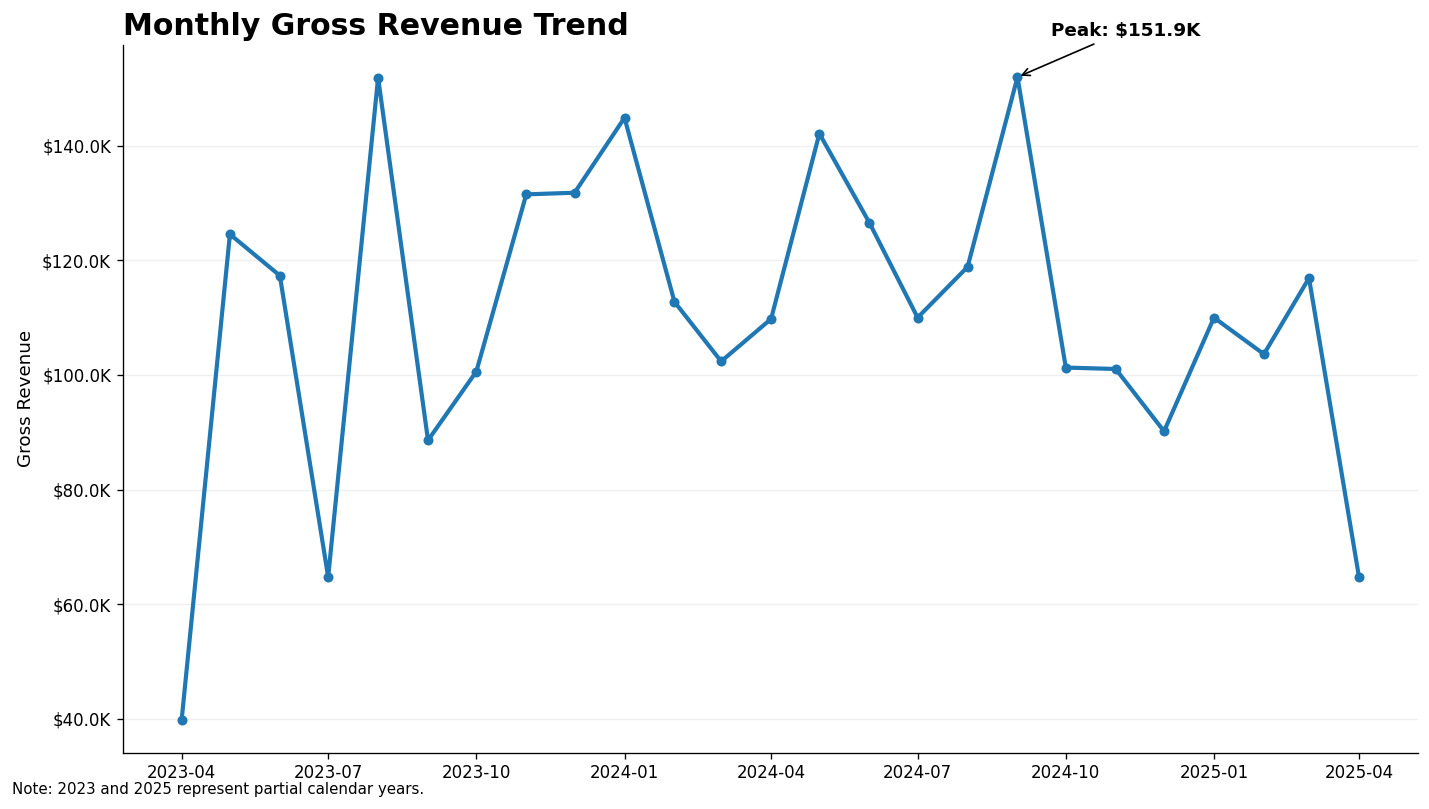

✓ Saved: /content/ecommerce_presentation/charts/02_revenue_by_category.png


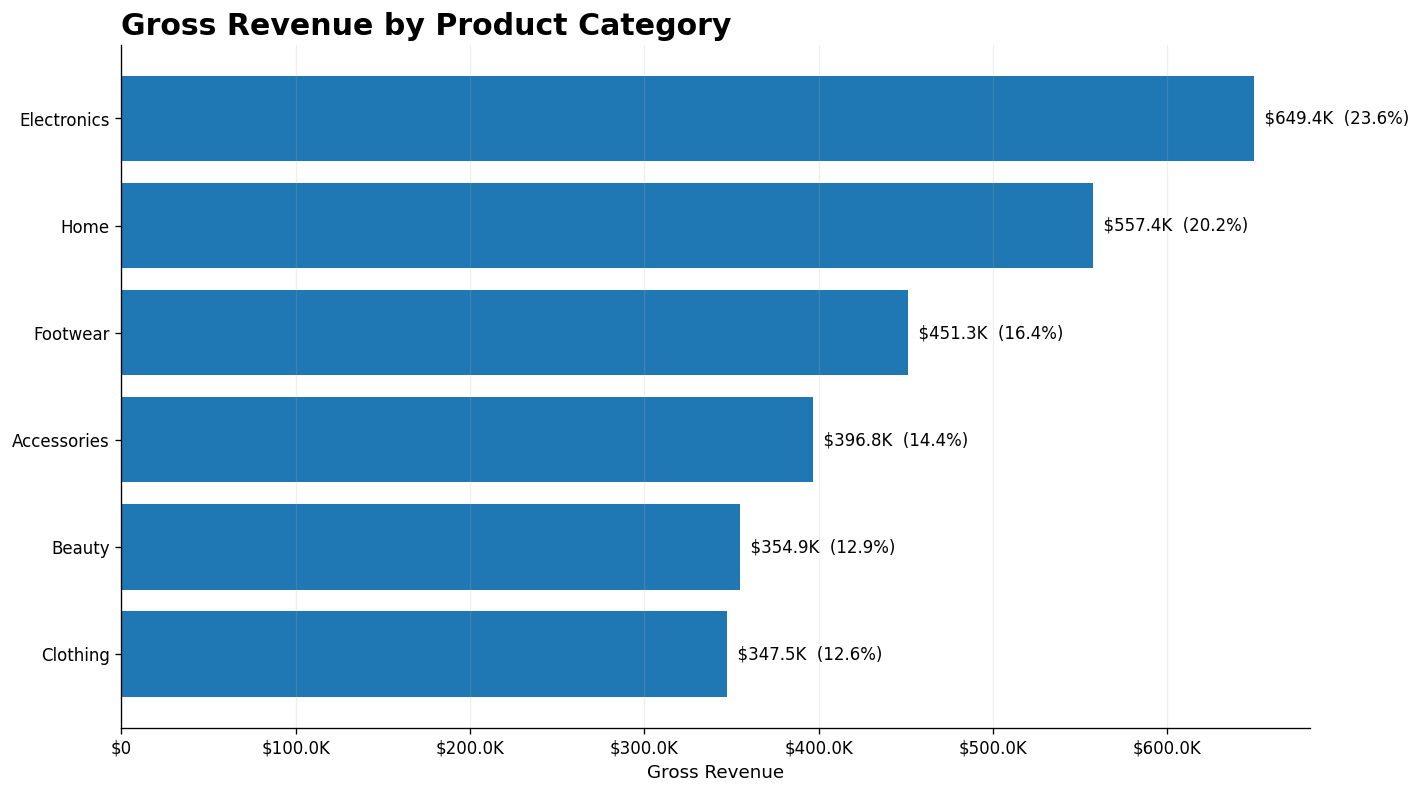

✓ Saved: /content/ecommerce_presentation/charts/03_revenue_by_region.png


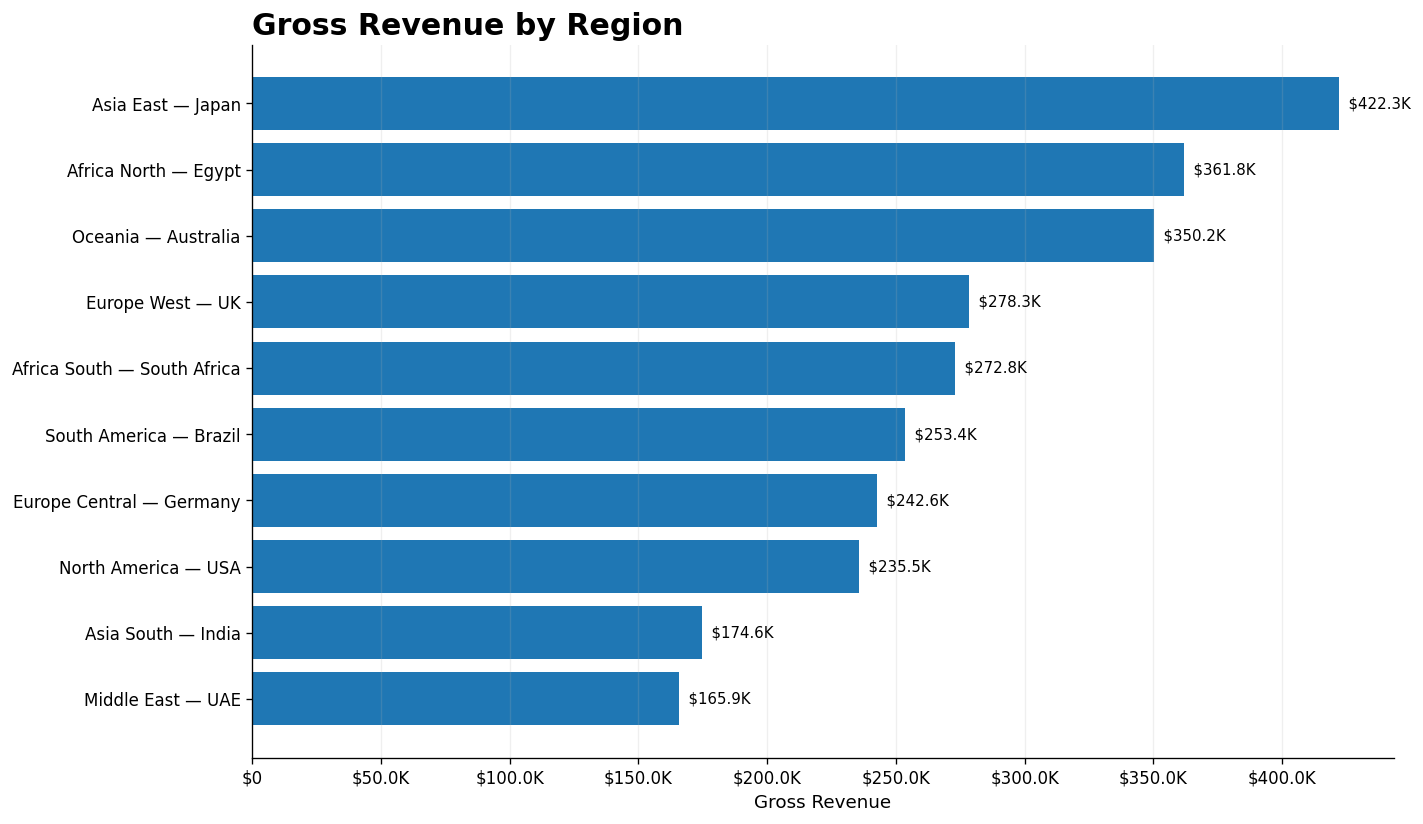

✓ Saved: /content/ecommerce_presentation/charts/04_top_10_products_revenue.png


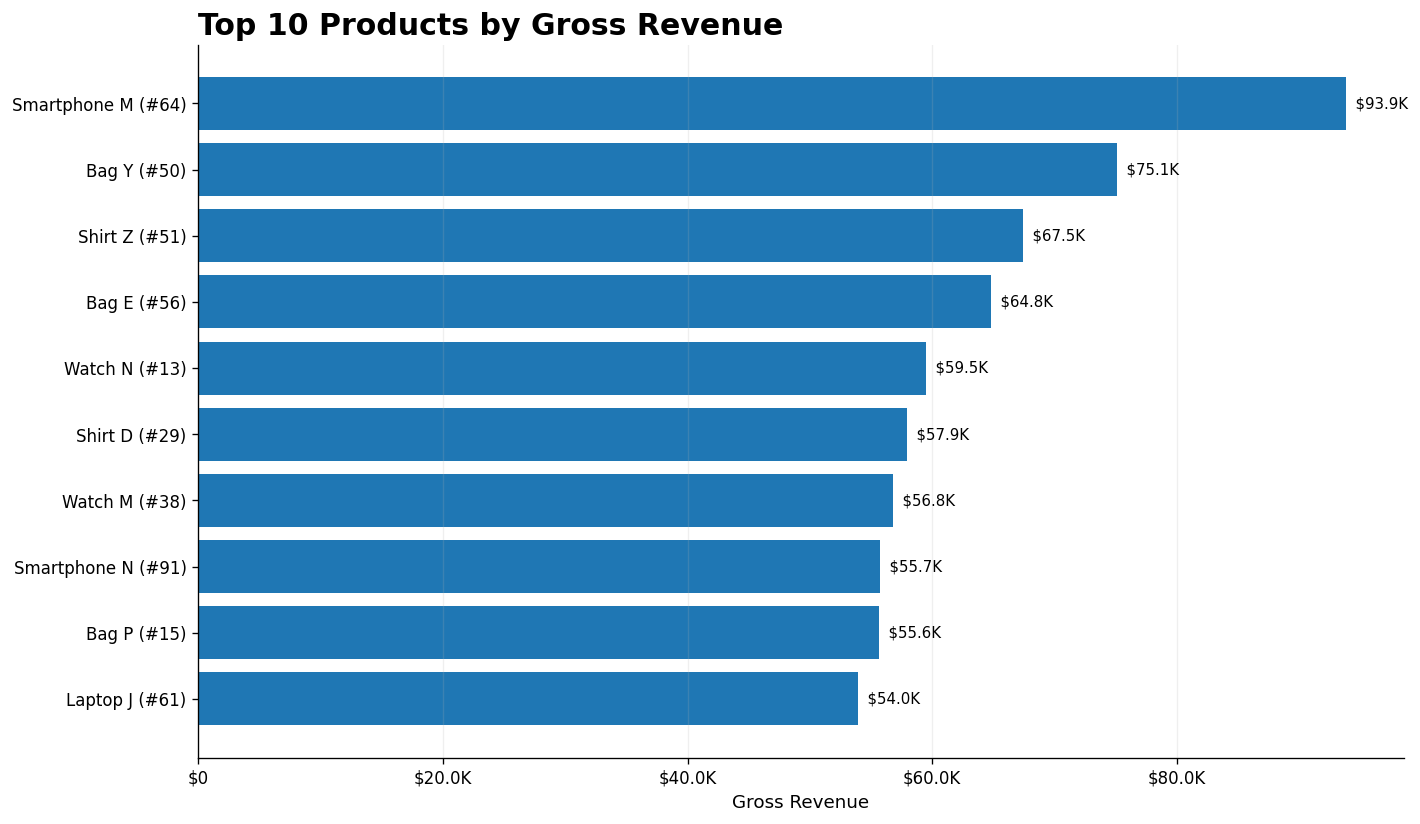

✓ Saved: /content/ecommerce_presentation/charts/05_top_10_customers.png


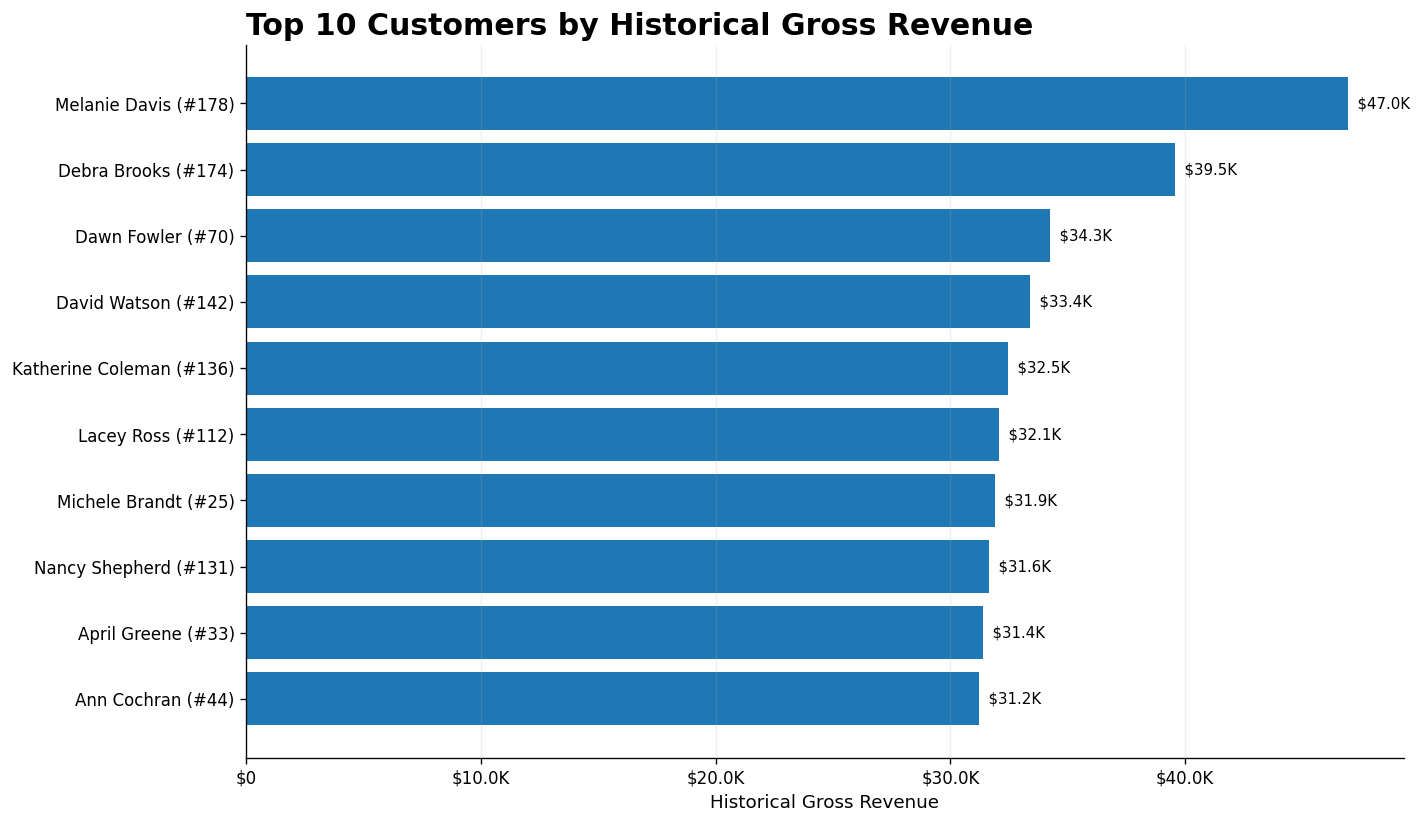


STAGE 4B VALIDATION
PASS | 25 calendar months represented
PASS | Monthly revenue reconciles to gross revenue
PASS | Category revenue reconciles to gross revenue
PASS | Regional revenue reconciles to gross revenue
PASS | Top 10 products created
PASS | Top 10 customers created
------------------------------------------------------------------------
RESULT: 6/6 checks passed

✓ STAGE 4B COMPLETE — core presentation charts created.


In [9]:
# ============================================================
# STAGE 4B — CORE PRESENTATION CHARTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# PRESENTATION SETTINGS
# ------------------------------------------------------------

plt.rcParams.update({
    "figure.figsize": (12, 6.75),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 18,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CHART_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def money_short(value):
    """Format large monetary values for chart labels."""
    if abs(value) >= 1_000_000:
        return f"${value / 1_000_000:.2f}M"
    if abs(value) >= 1_000:
        return f"${value / 1_000:.1f}K"
    return f"${value:,.0f}"


def save_chart(filename):
    """Save current figure as presentation-ready PNG."""
    path = CHART_DIR / filename

    plt.tight_layout()

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    print(f"✓ Saved: {path}")

    plt.show()
    plt.close()


# ============================================================
# CHART 1 — MONTHLY GROSS REVENUE TREND
# ============================================================

monthly_revenue = (
    sales
    .assign(
        Month=sales["OrderDate"].dt.to_period("M")
    )
    .groupby("Month", as_index=False)
    .agg(
        RevenueOrders=("OrderID", "nunique"),
        GrossRevenue=("LineRevenue", "sum")
    )
)

monthly_revenue["MonthDate"] = (
    monthly_revenue["Month"].dt.to_timestamp()
)

monthly_revenue.to_csv(
    TABLE_DIR / "monthly_revenue.csv",
    index=False
)

peak_month = monthly_revenue.loc[
    monthly_revenue["GrossRevenue"].idxmax()
]

fig, ax = plt.subplots(figsize=(12, 6.75))

ax.plot(
    monthly_revenue["MonthDate"],
    monthly_revenue["GrossRevenue"],
    marker="o",
    linewidth=2.5,
    markersize=5
)

ax.set_title(
    "Monthly Gross Revenue Trend",
    loc="left",
    fontweight="bold"
)

ax.set_ylabel("Gross Revenue")
ax.set_xlabel("")

ax.grid(
    axis="y",
    alpha=0.20
)

ax.yaxis.set_major_formatter(
    lambda x, pos: money_short(x)
)

ax.annotate(
    f"Peak: {money_short(peak_month['GrossRevenue'])}",
    xy=(
        peak_month["MonthDate"],
        peak_month["GrossRevenue"]
    ),
    xytext=(20, 25),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
        "connectionstyle": "arc3"
    },
    fontweight="bold"
)

fig.text(
    0.01,
    0.01,
    "Note: 2023 and 2025 represent partial calendar years.",
    fontsize=9
)

save_chart("01_monthly_revenue_trend.png")


# ============================================================
# CHART 2 — GROSS REVENUE BY CATEGORY
# ============================================================

category_revenue = (
    sales
    .groupby("Category", as_index=False)
    .agg(
        UnitsSold=("Quantity", "sum"),
        GrossRevenue=("LineRevenue", "sum")
    )
    .sort_values(
        "GrossRevenue",
        ascending=True
    )
)

category_revenue["RevenueSharePct"] = (
    category_revenue["GrossRevenue"]
    / category_revenue["GrossRevenue"].sum()
    * 100
)

category_revenue.to_csv(
    TABLE_DIR / "category_revenue.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 6.75))

bars = ax.barh(
    category_revenue["Category"],
    category_revenue["GrossRevenue"]
)

ax.set_title(
    "Gross Revenue by Product Category",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Gross Revenue")
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.20
)

ax.xaxis.set_major_formatter(
    lambda x, pos: money_short(x)
)

for bar, (_, row) in zip(
    bars,
    category_revenue.iterrows()
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        (
            f"  {money_short(row['GrossRevenue'])}"
            f"  ({row['RevenueSharePct']:.1f}%)"
        ),
        va="center",
        fontsize=10
    )

save_chart("02_revenue_by_category.png")


# ============================================================
# CHART 3 — REGIONAL GROSS REVENUE
# ============================================================

regional_revenue = (
    sales
    .groupby(
        ["RegionName", "Country"],
        as_index=False
    )
    .agg(
        RevenueOrders=("OrderID", "nunique"),
        UnitsSold=("Quantity", "sum"),
        GrossRevenue=("LineRevenue", "sum")
    )
)

regional_revenue["RegionLabel"] = (
    regional_revenue["RegionName"]
    + " — "
    + regional_revenue["Country"]
)

regional_revenue = regional_revenue.sort_values(
    "GrossRevenue",
    ascending=True
)

regional_revenue.to_csv(
    TABLE_DIR / "regional_revenue.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    regional_revenue["RegionLabel"],
    regional_revenue["GrossRevenue"]
)

ax.set_title(
    "Gross Revenue by Region",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Gross Revenue")
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.20
)

ax.xaxis.set_major_formatter(
    lambda x, pos: money_short(x)
)

for bar, value in zip(
    bars,
    regional_revenue["GrossRevenue"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {money_short(value)}",
        va="center",
        fontsize=9
    )

save_chart("03_revenue_by_region.png")


# ============================================================
# CHART 4 — TOP 10 PRODUCTS BY GROSS REVENUE
# ============================================================

product_revenue = (
    sales
    .groupby(
        ["ProductID", "ProductName", "Category"],
        as_index=False
    )
    .agg(
        UnitsSold=("Quantity", "sum"),
        GrossRevenue=("LineRevenue", "sum")
    )
)

top_products = (
    product_revenue
    .nlargest(10, "GrossRevenue")
    .sort_values(
        "GrossRevenue",
        ascending=True
    )
    .copy()
)

# ProductID is deliberately included because product names
# are not unique in this dataset.
top_products["ProductLabel"] = (
    top_products["ProductName"]
    + " (#"
    + top_products["ProductID"].astype(str)
    + ")"
)

top_products.to_csv(
    TABLE_DIR / "top_10_products_revenue.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top_products["ProductLabel"],
    top_products["GrossRevenue"]
)

ax.set_title(
    "Top 10 Products by Gross Revenue",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Gross Revenue")
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.20
)

ax.xaxis.set_major_formatter(
    lambda x, pos: money_short(x)
)

for bar, value in zip(
    bars,
    top_products["GrossRevenue"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {money_short(value)}",
        va="center",
        fontsize=9
    )

save_chart("04_top_10_products_revenue.png")


# ============================================================
# CHART 5 — TOP 10 CUSTOMERS BY GROSS REVENUE
# ============================================================

customer_revenue = (
    sales
    .groupby(
        [
            "CustomerID",
            "CustomerName",
            "RegionName",
            "Country"
        ],
        as_index=False
    )
    .agg(
        RevenueOrders=("OrderID", "nunique"),
        UnitsPurchased=("Quantity", "sum"),
        GrossRevenue=("LineRevenue", "sum")
    )
)

top_customers = (
    customer_revenue
    .nlargest(10, "GrossRevenue")
    .sort_values(
        "GrossRevenue",
        ascending=True
    )
    .copy()
)

top_customers["CustomerLabel"] = (
    top_customers["CustomerName"]
    + " (#"
    + top_customers["CustomerID"].astype(str)
    + ")"
)

top_customers.to_csv(
    TABLE_DIR / "top_10_customers_revenue.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top_customers["CustomerLabel"],
    top_customers["GrossRevenue"]
)

ax.set_title(
    "Top 10 Customers by Historical Gross Revenue",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Historical Gross Revenue")
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.20
)

ax.xaxis.set_major_formatter(
    lambda x, pos: money_short(x)
)

for bar, value in zip(
    bars,
    top_customers["GrossRevenue"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {money_short(value)}",
        va="center",
        fontsize=9
    )

save_chart("05_top_10_customers.png")


# ============================================================
# STAGE 4B VALIDATION
# ============================================================

print("\n" + "=" * 72)
print("STAGE 4B VALIDATION")
print("=" * 72)

checks = [
    (
        len(monthly_revenue) == 25,
        "25 calendar months represented"
    ),
    (
        abs(
            monthly_revenue["GrossRevenue"].sum()
            - gross_revenue
        ) < 0.01,
        "Monthly revenue reconciles to gross revenue"
    ),
    (
        abs(
            category_revenue["GrossRevenue"].sum()
            - gross_revenue
        ) < 0.01,
        "Category revenue reconciles to gross revenue"
    ),
    (
        abs(
            regional_revenue["GrossRevenue"].sum()
            - gross_revenue
        ) < 0.01,
        "Regional revenue reconciles to gross revenue"
    ),
    (
        len(top_products) == 10,
        "Top 10 products created"
    ),
    (
        len(top_customers) == 10,
        "Top 10 customers created"
    ),
]

passed = 0

for status, description in checks:
    if status:
        print(f"PASS | {description}")
        passed += 1
    else:
        print(f"FAIL | {description}")

print("-" * 72)
print(f"RESULT: {passed}/{len(checks)} checks passed")

if passed == len(checks):
    print(
        "\n✓ STAGE 4B COMPLETE — "
        "core presentation charts created."
    )
else:
    print(
        "\n⚠ Stop before continuing."
    )

## Stage 4C — Customer, AOV & Return-Risk Analysis

This section visualizes customer segmentation, purchasing frequency,
average order value, return exposure, regional return risk,
data completeness, and weekday sales performance.

✓ Saved: /content/ecommerce_presentation/charts/06_customer_segments.png


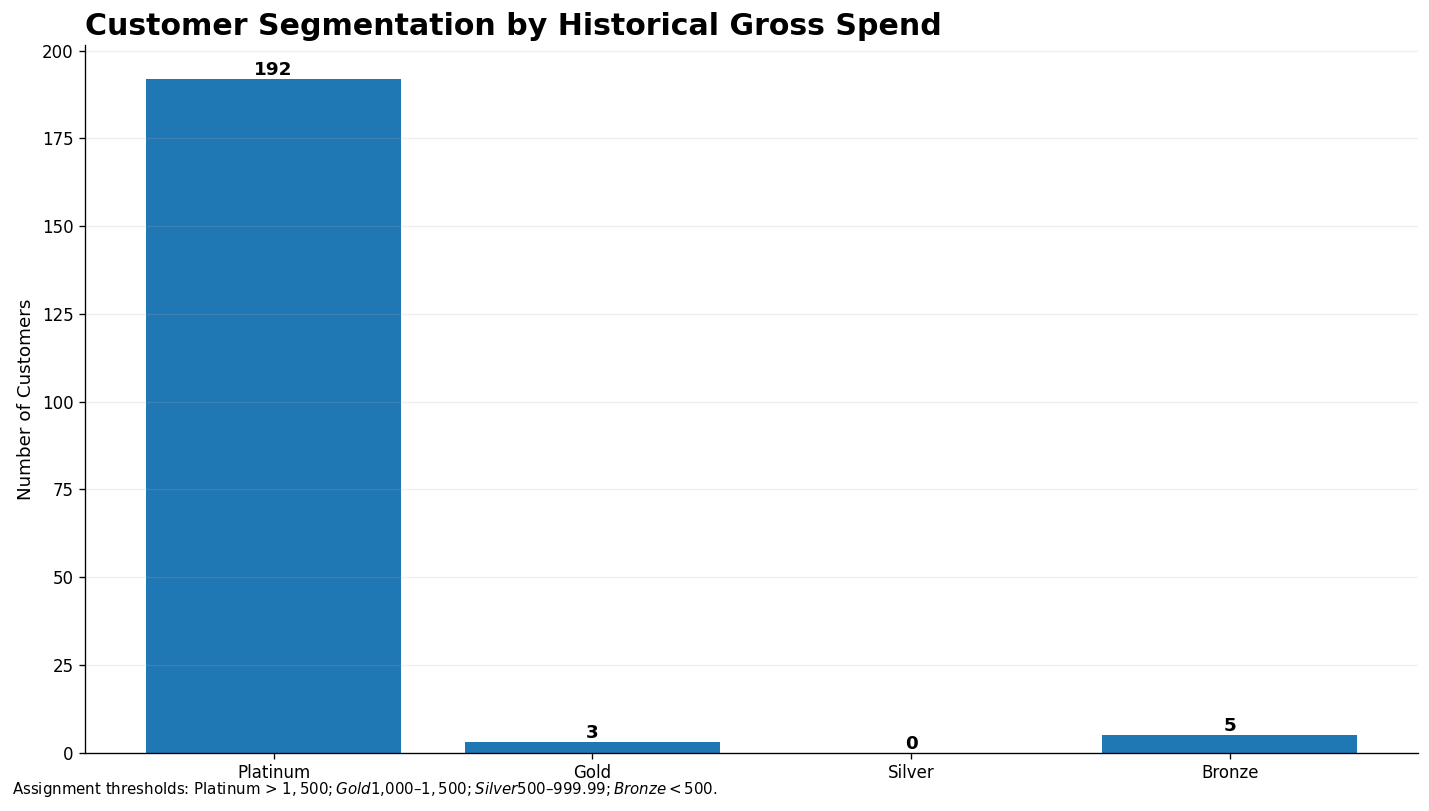

✓ Saved: /content/ecommerce_presentation/charts/07_purchase_frequency_by_region.png


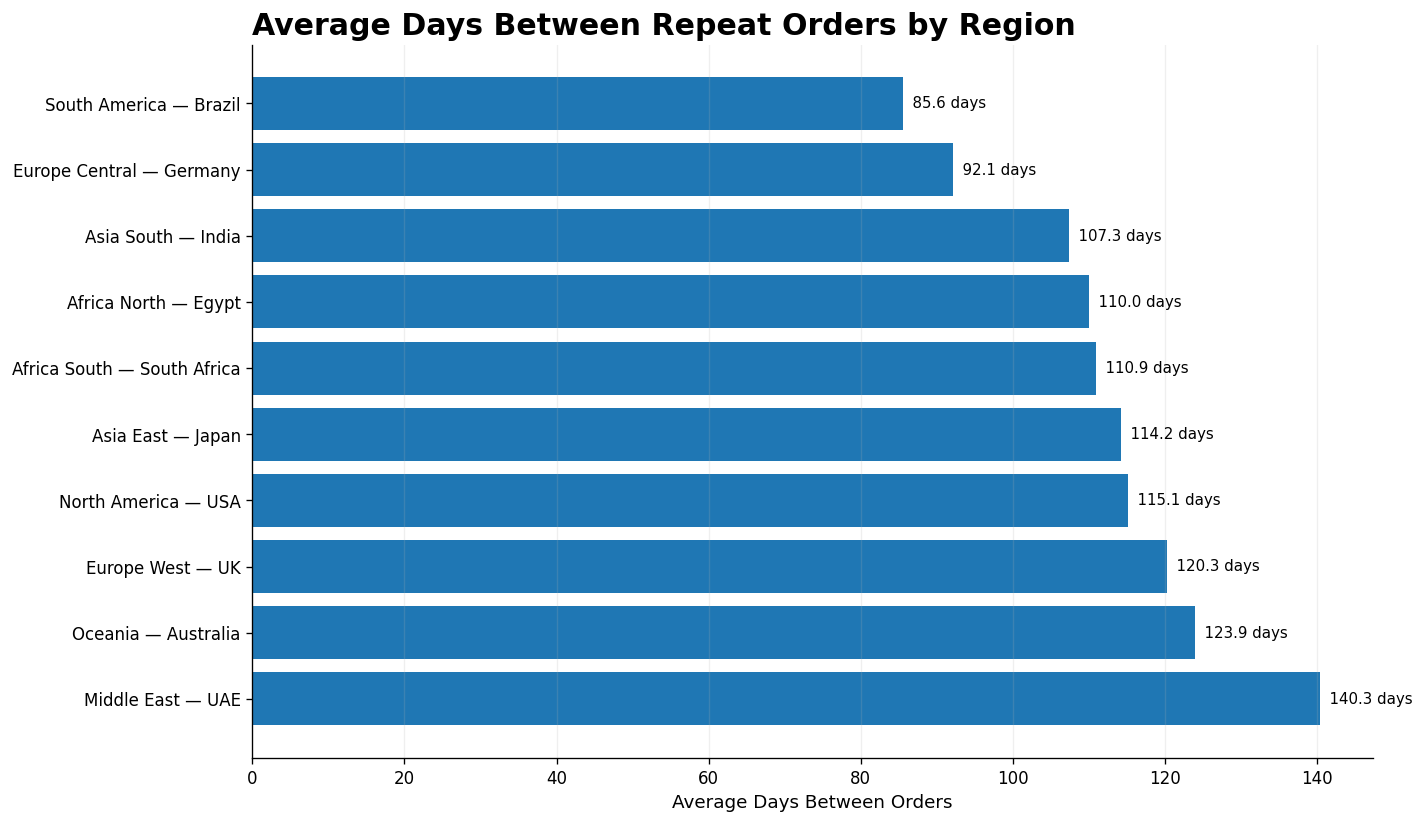

✓ Saved: /content/ecommerce_presentation/charts/08_monthly_aov_trend.png


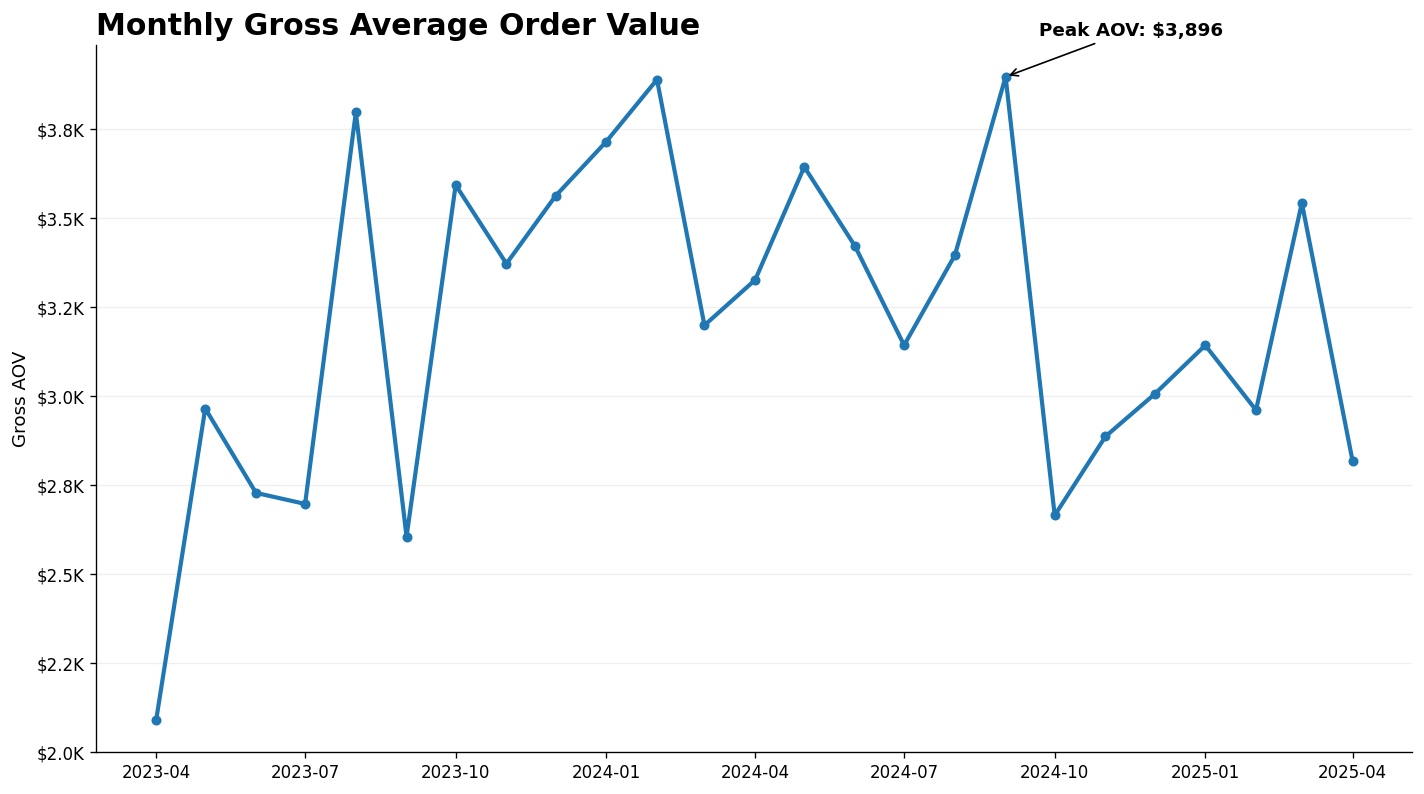

✓ Saved: /content/ecommerce_presentation/charts/09_category_return_rate.png


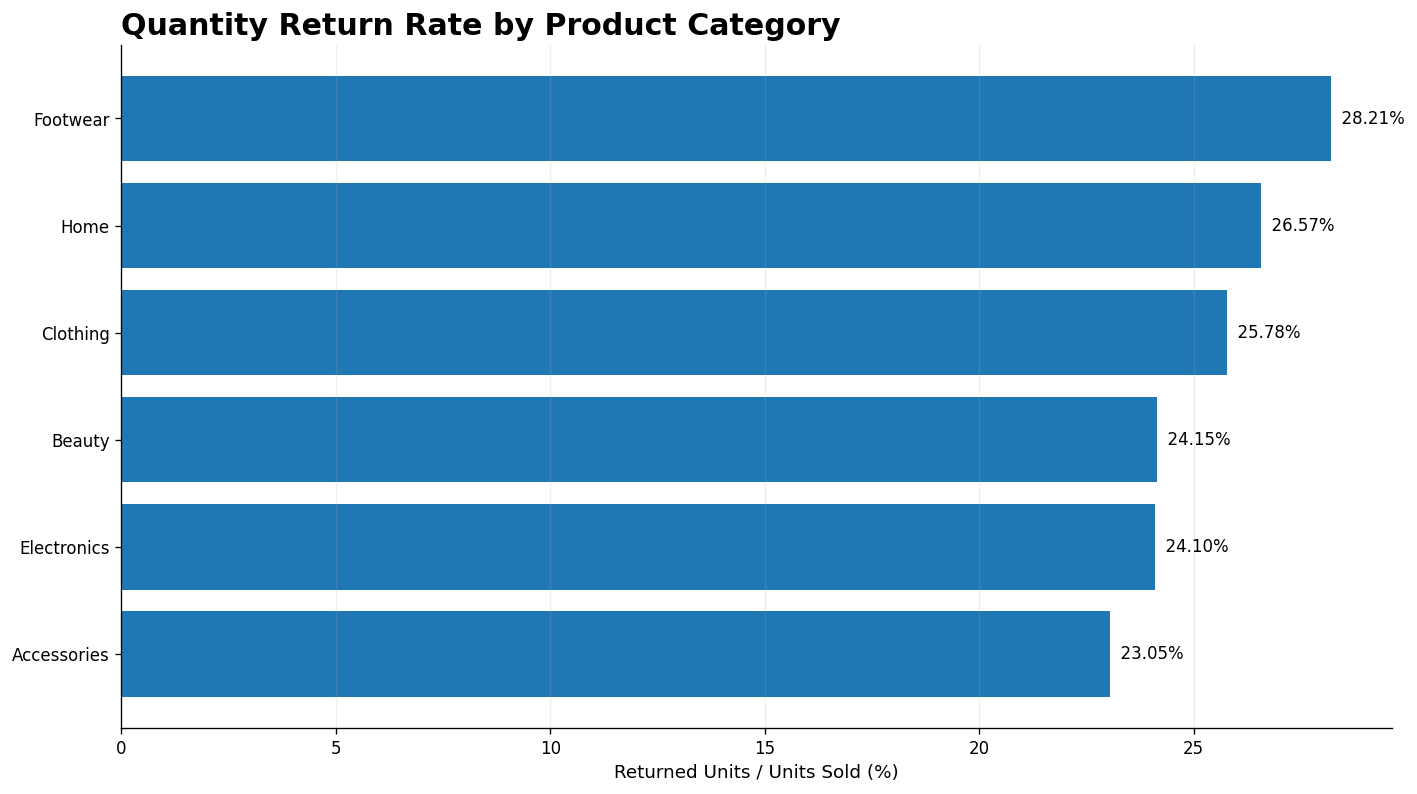

✓ Saved: /content/ecommerce_presentation/charts/10_category_returned_revenue.png


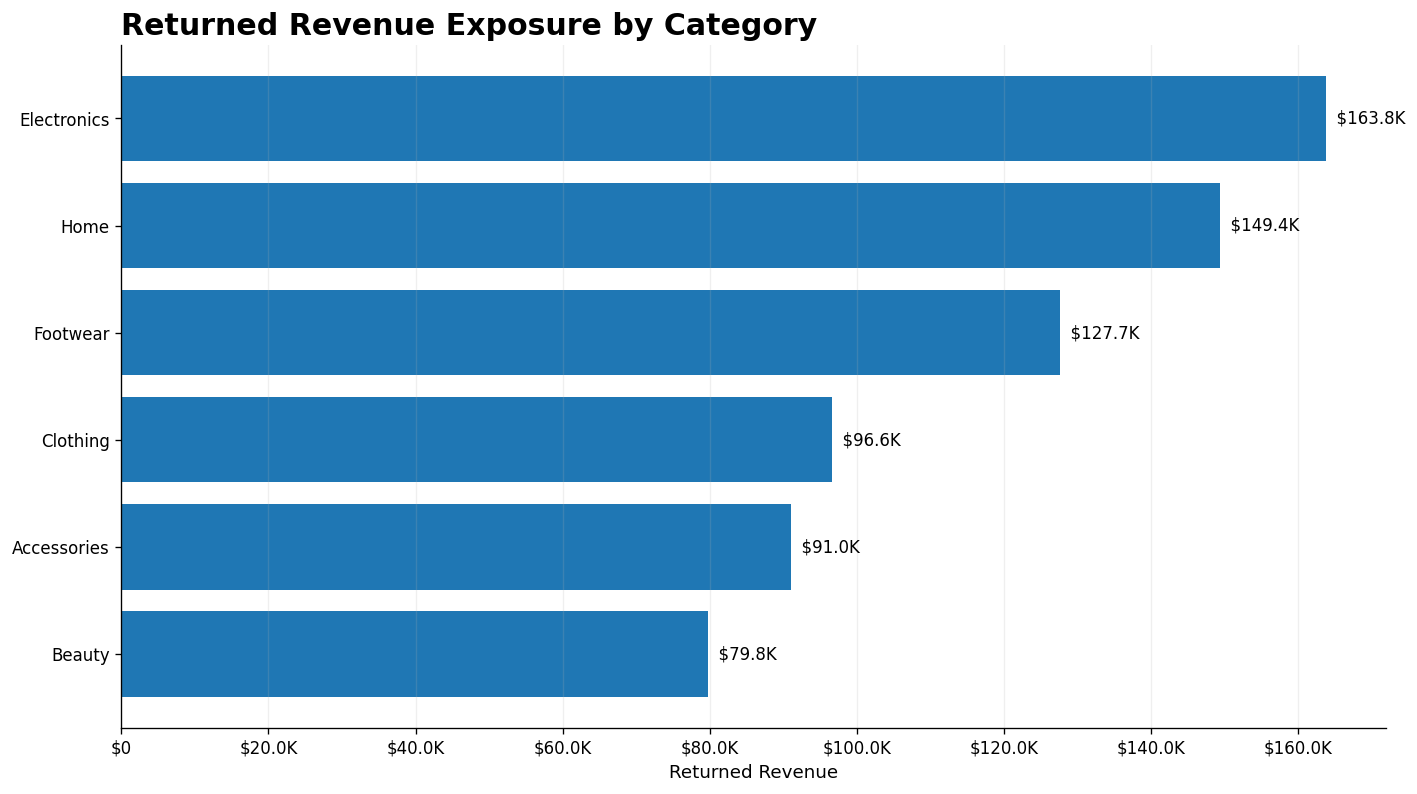

✓ Saved: /content/ecommerce_presentation/charts/11_regional_return_rate.png


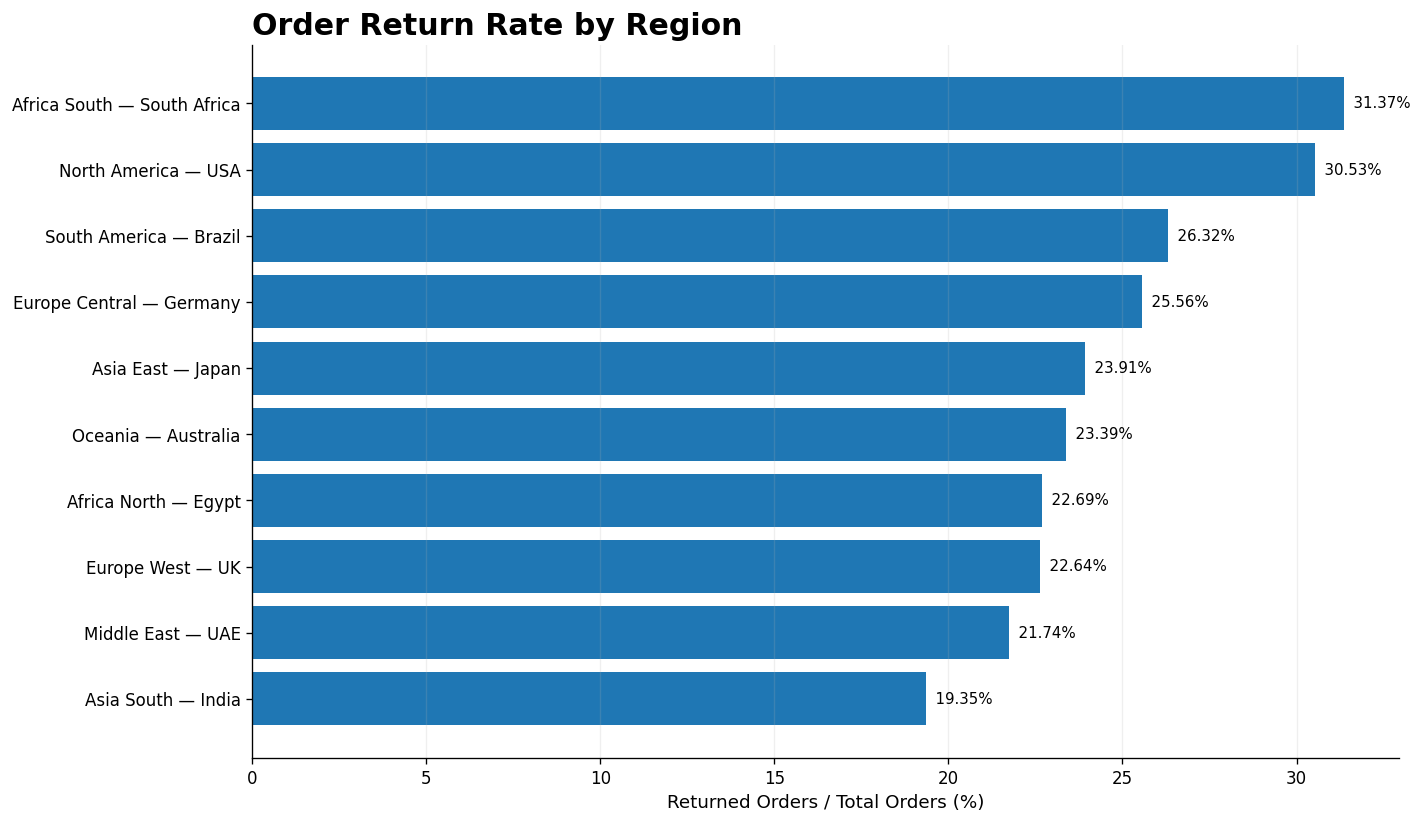

✓ Saved: /content/ecommerce_presentation/charts/12_regional_detail_coverage.png


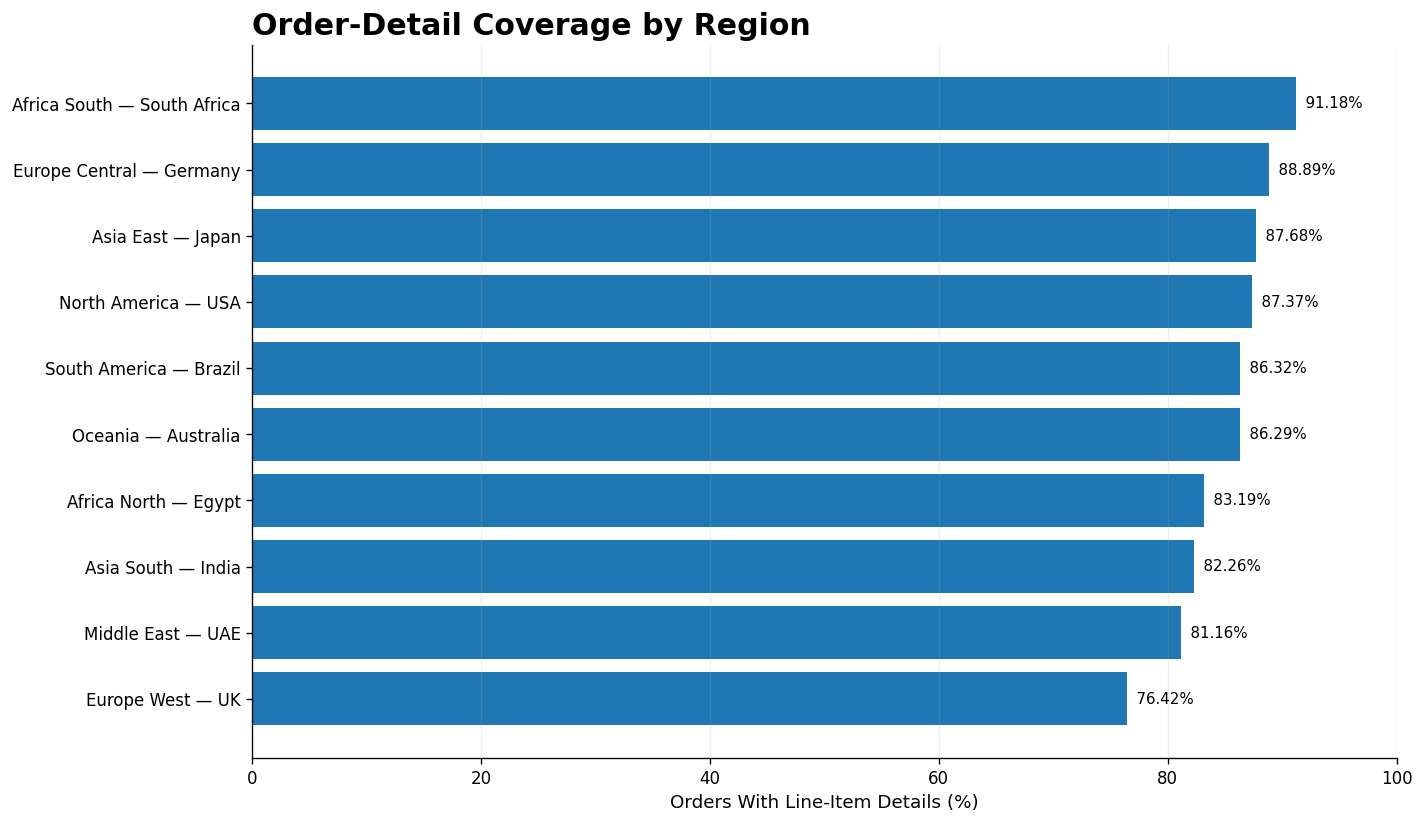

✓ Saved: /content/ecommerce_presentation/charts/13_weekday_revenue.png


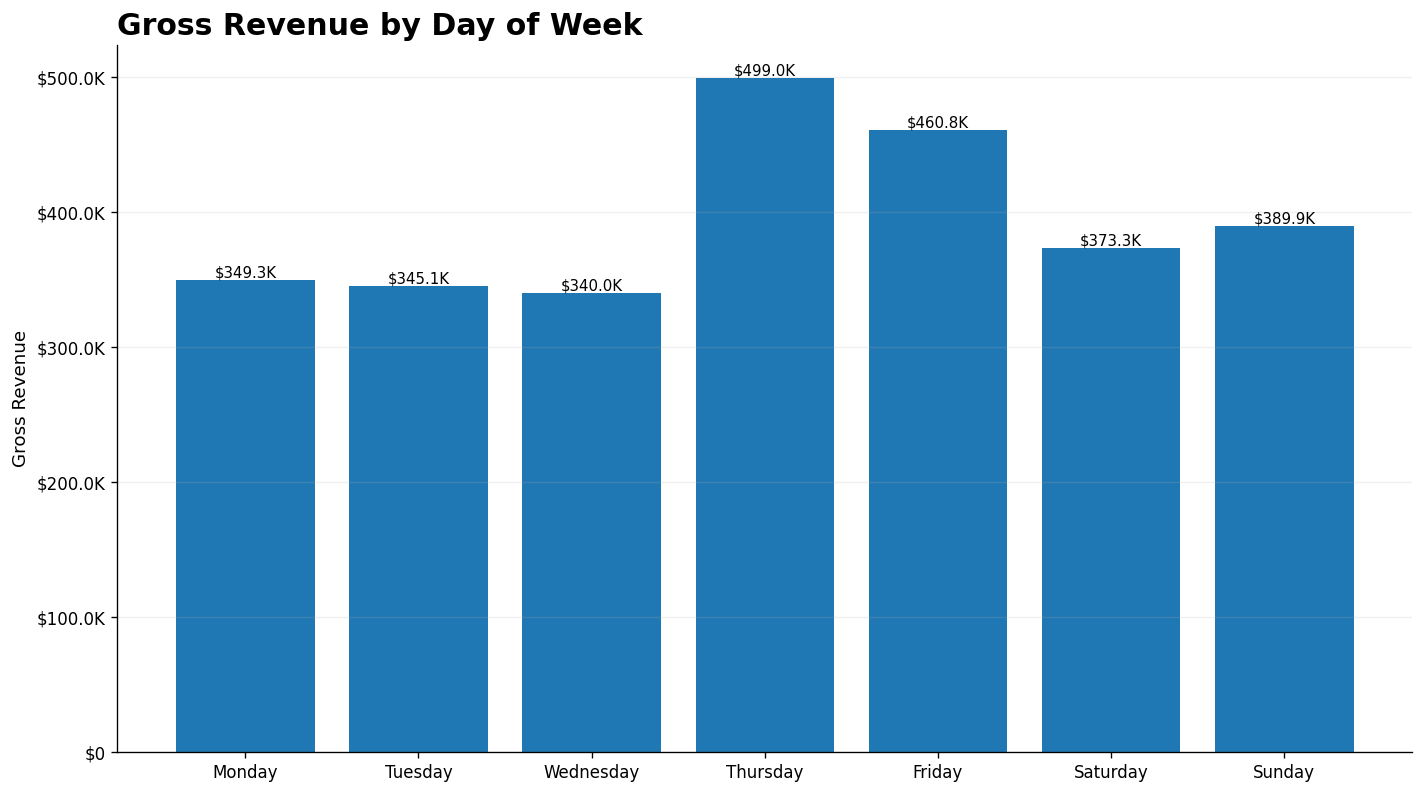


STAGE 4C VALIDATION
PASS | Customer segments contain all 200 customers
PASS | Purchase-frequency analysis contains 10 regions
PASS | Monthly AOV contains 25 calendar months
PASS | Category units reconcile to 6,015
PASS | Category returned units reconcile to 1,518
PASS | Category returned revenue reconciles
PASS | Regional orders reconcile to 1,000
PASS | Regional returned orders reconcile to 249
PASS | Regional coverage uses all 1,000 orders
PASS | Regional coverage identifies 853 revenue orders
PASS | Weekday analysis reconciles to 853 revenue orders
PASS | Weekday revenue reconciles to gross revenue
------------------------------------------------------------------------
RESULT: 12/12 checks passed

✓ STAGE 4C COMPLETE — customer and risk visualizations validated.


In [10]:
# ============================================================
# STAGE 4C — CUSTOMER, AOV & RETURN-RISK VISUALIZATIONS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CHART 6 — CUSTOMER SEGMENTS
# ============================================================

customer_spend = (
    customers[["CustomerID", "CustomerName"]]
    .merge(
        customer_revenue[
            ["CustomerID", "GrossRevenue"]
        ],
        on="CustomerID",
        how="left"
    )
)

customer_spend["GrossRevenue"] = (
    customer_spend["GrossRevenue"].fillna(0)
)

customer_spend["Segment"] = np.select(
    [
        customer_spend["GrossRevenue"] > 1500,
        customer_spend["GrossRevenue"] >= 1000,
        customer_spend["GrossRevenue"] >= 500,
    ],
    [
        "Platinum",
        "Gold",
        "Silver",
    ],
    default="Bronze"
)

segment_order = [
    "Platinum",
    "Gold",
    "Silver",
    "Bronze"
]

customer_segments = (
    customer_spend
    .groupby("Segment", as_index=False)
    .agg(
        Customers=("CustomerID", "count"),
        GrossRevenue=("GrossRevenue", "sum"),
        AvgCustomerSpend=("GrossRevenue", "mean")
    )
)

# Ensure missing segments still appear
customer_segments = (
    pd.DataFrame({"Segment": segment_order})
    .merge(
        customer_segments,
        on="Segment",
        how="left"
    )
    .fillna(0)
)

customer_segments["Segment"] = pd.Categorical(
    customer_segments["Segment"],
    categories=segment_order,
    ordered=True
)

customer_segments = (
    customer_segments
    .sort_values("Segment")
)

customer_segments.to_csv(
    TABLE_DIR / "customer_segments.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 6.75))

bars = ax.bar(
    customer_segments["Segment"].astype(str),
    customer_segments["Customers"]
)

ax.set_title(
    "Customer Segmentation by Historical Gross Spend",
    loc="left",
    fontweight="bold"
)

ax.set_ylabel("Number of Customers")
ax.set_xlabel("")

ax.grid(
    axis="y",
    alpha=0.20
)

for bar, value in zip(
    bars,
    customer_segments["Customers"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

fig.text(
    0.01,
    0.01,
    (
        "Assignment thresholds: Platinum > $1,500; "
        "Gold $1,000–$1,500; Silver $500–$999.99; "
        "Bronze < $500."
    ),
    fontsize=9
)

save_chart("06_customer_segments.png")


# ============================================================
# CHART 7 — PURCHASE FREQUENCY BY REGION
# Average days between consecutive orders
# ============================================================

orders_frequency = (
    orders[
        ["OrderID", "CustomerID", "OrderDate"]
    ]
    .merge(
        customers[
            ["CustomerID", "RegionID"]
        ],
        on="CustomerID",
        how="left"
    )
    .merge(
        regions,
        on="RegionID",
        how="left"
    )
    .sort_values(
        ["CustomerID", "OrderDate", "OrderID"]
    )
)

orders_frequency["PreviousOrderDate"] = (
    orders_frequency
    .groupby("CustomerID")["OrderDate"]
    .shift(1)
)

orders_frequency["DaysBetweenOrders"] = (
    orders_frequency["OrderDate"]
    - orders_frequency["PreviousOrderDate"]
).dt.days

regional_frequency = (
    orders_frequency
    .dropna(subset=["DaysBetweenOrders"])
    .groupby(
        ["RegionName", "Country"],
        as_index=False
    )
    .agg(
        RepeatIntervals=("DaysBetweenOrders", "count"),
        AvgDaysBetweenOrders=("DaysBetweenOrders", "mean")
    )
    .sort_values(
        "AvgDaysBetweenOrders",
        ascending=False
    )
)

regional_frequency["RegionLabel"] = (
    regional_frequency["RegionName"]
    + " — "
    + regional_frequency["Country"]
)

regional_frequency.to_csv(
    TABLE_DIR / "regional_purchase_frequency.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    regional_frequency["RegionLabel"],
    regional_frequency["AvgDaysBetweenOrders"]
)

ax.set_title(
    "Average Days Between Repeat Orders by Region",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Average Days Between Orders")
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.20
)

for bar, value in zip(
    bars,
    regional_frequency["AvgDaysBetweenOrders"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {value:.1f} days",
        va="center",
        fontsize=9
    )

save_chart("07_purchase_frequency_by_region.png")


# ============================================================
# CHART 8 — MONTHLY GROSS AOV TREND
# ============================================================

monthly_aov = (
    order_revenue
    .assign(
        Month=order_revenue["OrderDate"].dt.to_period("M")
    )
    .groupby("Month", as_index=False)
    .agg(
        RevenueOrders=("OrderID", "nunique"),
        GrossRevenue=("GrossRevenue", "sum"),
        GrossAOV=("GrossRevenue", "mean")
    )
)

monthly_aov["MonthDate"] = (
    monthly_aov["Month"].dt.to_timestamp()
)

monthly_aov.to_csv(
    TABLE_DIR / "monthly_aov.csv",
    index=False
)

peak_aov = monthly_aov.loc[
    monthly_aov["GrossAOV"].idxmax()
]

fig, ax = plt.subplots(figsize=(12, 6.75))

ax.plot(
    monthly_aov["MonthDate"],
    monthly_aov["GrossAOV"],
    marker="o",
    linewidth=2.5,
    markersize=5
)

ax.set_title(
    "Monthly Gross Average Order Value",
    loc="left",
    fontweight="bold"
)

ax.set_ylabel("Gross AOV")
ax.set_xlabel("")

ax.grid(
    axis="y",
    alpha=0.20
)

ax.yaxis.set_major_formatter(
    lambda x, pos: money_short(x)
)

ax.annotate(
    (
        f"Peak AOV: "
        f"${peak_aov['GrossAOV']:,.0f}"
    ),
    xy=(
        peak_aov["MonthDate"],
        peak_aov["GrossAOV"]
    ),
    xytext=(20, 25),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
    fontweight="bold"
)

save_chart("08_monthly_aov_trend.png")


# ============================================================
# PREPARE RETURN-ENRICHED SALES TABLE
# ============================================================

return_sales = sales.copy()

return_sales["ReturnedUnits"] = np.where(
    return_sales["IsReturned"] == 1,
    return_sales["Quantity"],
    0
)

return_sales["ReturnedRevenue"] = np.where(
    return_sales["IsReturned"] == 1,
    return_sales["LineRevenue"],
    0
)


# ============================================================
# CHART 9 — CATEGORY QUANTITY RETURN RATE
# ============================================================

category_returns = (
    return_sales
    .groupby("Category", as_index=False)
    .agg(
        UnitsSold=("Quantity", "sum"),
        ReturnedUnits=("ReturnedUnits", "sum"),
        ReturnedRevenue=("ReturnedRevenue", "sum")
    )
)

category_returns["QuantityReturnRatePct"] = (
    category_returns["ReturnedUnits"]
    / category_returns["UnitsSold"]
    * 100
)

category_returns = (
    category_returns
    .sort_values(
        "QuantityReturnRatePct",
        ascending=True
    )
)

category_returns.to_csv(
    TABLE_DIR / "category_returns.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 6.75))

bars = ax.barh(
    category_returns["Category"],
    category_returns["QuantityReturnRatePct"]
)

ax.set_title(
    "Quantity Return Rate by Product Category",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Returned Units / Units Sold (%)")
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.20
)

for bar, value in zip(
    bars,
    category_returns["QuantityReturnRatePct"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {value:.2f}%",
        va="center",
        fontsize=10
    )

save_chart("09_category_return_rate.png")


# ============================================================
# CHART 10 — RETURNED REVENUE BY CATEGORY
# ============================================================

category_return_revenue = (
    category_returns
    .sort_values(
        "ReturnedRevenue",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(12, 6.75))

bars = ax.barh(
    category_return_revenue["Category"],
    category_return_revenue["ReturnedRevenue"]
)

ax.set_title(
    "Returned Revenue Exposure by Category",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Returned Revenue")
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.20
)

ax.xaxis.set_major_formatter(
    lambda x, pos: money_short(x)
)

for bar, value in zip(
    bars,
    category_return_revenue["ReturnedRevenue"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {money_short(value)}",
        va="center",
        fontsize=10
    )

save_chart("10_category_returned_revenue.png")


# ============================================================
# CHART 11 — REGIONAL ORDER RETURN RATE
# ============================================================

regional_orders = (
    orders[
        ["OrderID", "CustomerID", "IsReturned"]
    ]
    .merge(
        customers[
            ["CustomerID", "RegionID"]
        ],
        on="CustomerID",
        how="left"
    )
    .merge(
        regions,
        on="RegionID",
        how="left"
    )
)

regional_returns = (
    regional_orders
    .groupby(
        ["RegionName", "Country"],
        as_index=False
    )
    .agg(
        TotalOrders=("OrderID", "nunique"),
        ReturnedOrders=("IsReturned", "sum")
    )
)

regional_returns["OrderReturnRatePct"] = (
    regional_returns["ReturnedOrders"]
    / regional_returns["TotalOrders"]
    * 100
)

regional_returns["RegionLabel"] = (
    regional_returns["RegionName"]
    + " — "
    + regional_returns["Country"]
)

regional_returns = (
    regional_returns
    .sort_values(
        "OrderReturnRatePct",
        ascending=True
    )
)

regional_returns.to_csv(
    TABLE_DIR / "regional_returns.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    regional_returns["RegionLabel"],
    regional_returns["OrderReturnRatePct"]
)

ax.set_title(
    "Order Return Rate by Region",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Returned Orders / Total Orders (%)")
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.20
)

for bar, value in zip(
    bars,
    regional_returns["OrderReturnRatePct"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {value:.2f}%",
        va="center",
        fontsize=9
    )

save_chart("11_regional_return_rate.png")


# ============================================================
# CHART 12 — ORDER-DETAIL COVERAGE BY REGION
# ============================================================

all_regional_orders = (
    orders[
        ["OrderID", "CustomerID"]
    ]
    .merge(
        customers[
            ["CustomerID", "RegionID"]
        ],
        on="CustomerID",
        how="left"
    )
    .merge(
        regions,
        on="RegionID",
        how="left"
    )
)

regional_total_orders = (
    all_regional_orders
    .groupby(
        ["RegionName", "Country"],
        as_index=False
    )
    .agg(
        TotalOrders=("OrderID", "nunique")
    )
)

revenue_order_ids = (
    orderdetails["OrderID"]
    .drop_duplicates()
)

regional_detail_orders = (
    all_regional_orders[
        all_regional_orders["OrderID"]
        .isin(revenue_order_ids)
    ]
    .groupby(
        ["RegionName", "Country"],
        as_index=False
    )
    .agg(
        RevenueOrders=("OrderID", "nunique")
    )
)

regional_coverage = (
    regional_total_orders
    .merge(
        regional_detail_orders,
        on=["RegionName", "Country"],
        how="left"
    )
)

regional_coverage["RevenueOrders"] = (
    regional_coverage["RevenueOrders"]
    .fillna(0)
)

regional_coverage["DetailCoveragePct"] = (
    regional_coverage["RevenueOrders"]
    / regional_coverage["TotalOrders"]
    * 100
)

regional_coverage["RegionLabel"] = (
    regional_coverage["RegionName"]
    + " — "
    + regional_coverage["Country"]
)

regional_coverage = (
    regional_coverage
    .sort_values(
        "DetailCoveragePct",
        ascending=True
    )
)

regional_coverage.to_csv(
    TABLE_DIR / "regional_detail_coverage.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    regional_coverage["RegionLabel"],
    regional_coverage["DetailCoveragePct"]
)

ax.set_title(
    "Order-Detail Coverage by Region",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Orders With Line-Item Details (%)")
ax.set_ylabel("")

ax.set_xlim(0, 100)

ax.grid(
    axis="x",
    alpha=0.20
)

for bar, value in zip(
    bars,
    regional_coverage["DetailCoveragePct"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {value:.2f}%",
        va="center",
        fontsize=9
    )

save_chart("12_regional_detail_coverage.png")


# ============================================================
# CHART 13 — WEEKDAY GROSS REVENUE
# ============================================================

weekday_order_revenue = (
    order_revenue.copy()
)

weekday_order_revenue["DayNumber"] = (
    weekday_order_revenue["OrderDate"].dt.dayofweek
)

weekday_order_revenue["DayName"] = (
    weekday_order_revenue["OrderDate"].dt.day_name()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_summary = (
    weekday_order_revenue
    .groupby("DayName", as_index=False)
    .agg(
        RevenueOrders=("OrderID", "nunique"),
        GrossRevenue=("GrossRevenue", "sum"),
        GrossAOV=("GrossRevenue", "mean")
    )
)

weekday_summary["DayName"] = pd.Categorical(
    weekday_summary["DayName"],
    categories=day_order,
    ordered=True
)

weekday_summary = (
    weekday_summary
    .sort_values("DayName")
)

weekday_summary.to_csv(
    TABLE_DIR / "weekday_performance.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 6.75))

bars = ax.bar(
    weekday_summary["DayName"].astype(str),
    weekday_summary["GrossRevenue"]
)

ax.set_title(
    "Gross Revenue by Day of Week",
    loc="left",
    fontweight="bold"
)

ax.set_ylabel("Gross Revenue")
ax.set_xlabel("")

ax.grid(
    axis="y",
    alpha=0.20
)

ax.yaxis.set_major_formatter(
    lambda x, pos: money_short(x)
)

for bar, value in zip(
    bars,
    weekday_summary["GrossRevenue"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        money_short(value),
        ha="center",
        va="bottom",
        fontsize=9
    )

save_chart("13_weekday_revenue.png")


# ============================================================
# STAGE 4C VALIDATION
# ============================================================

print("\n" + "=" * 72)
print("STAGE 4C VALIDATION")
print("=" * 72)

checks = [
    (
        int(customer_segments["Customers"].sum()) == 200,
        "Customer segments contain all 200 customers"
    ),

    (
        len(regional_frequency) == 10,
        "Purchase-frequency analysis contains 10 regions"
    ),

    (
        len(monthly_aov) == 25,
        "Monthly AOV contains 25 calendar months"
    ),

    (
        int(category_returns["UnitsSold"].sum()) == 6015,
        "Category units reconcile to 6,015"
    ),

    (
        int(category_returns["ReturnedUnits"].sum()) == 1518,
        "Category returned units reconcile to 1,518"
    ),

    (
        abs(
            category_returns["ReturnedRevenue"].sum()
            - returned_revenue
        ) < 0.01,
        "Category returned revenue reconciles"
    ),

    (
        int(regional_returns["TotalOrders"].sum()) == 1000,
        "Regional orders reconcile to 1,000"
    ),

    (
        int(regional_returns["ReturnedOrders"].sum()) == 249,
        "Regional returned orders reconcile to 249"
    ),

    (
        int(regional_coverage["TotalOrders"].sum()) == 1000,
        "Regional coverage uses all 1,000 orders"
    ),

    (
        int(regional_coverage["RevenueOrders"].sum()) == 853,
        "Regional coverage identifies 853 revenue orders"
    ),

    (
        int(weekday_summary["RevenueOrders"].sum()) == 853,
        "Weekday analysis reconciles to 853 revenue orders"
    ),

    (
        abs(
            weekday_summary["GrossRevenue"].sum()
            - gross_revenue
        ) < 0.01,
        "Weekday revenue reconciles to gross revenue"
    ),
]

passed = 0

for status, description in checks:
    if status:
        print(f"PASS | {description}")
        passed += 1
    else:
        print(f"FAIL | {description}")

print("-" * 72)
print(
    f"RESULT: {passed}/{len(checks)} checks passed"
)

if passed == len(checks):
    print(
        "\n✓ STAGE 4C COMPLETE — "
        "customer and risk visualizations validated."
    )
else:
    print(
        "\n⚠ Stop here before creating the PPT."
    )

✓ Saved: /content/ecommerce_presentation/charts/14_category_monthly_heatmap.png


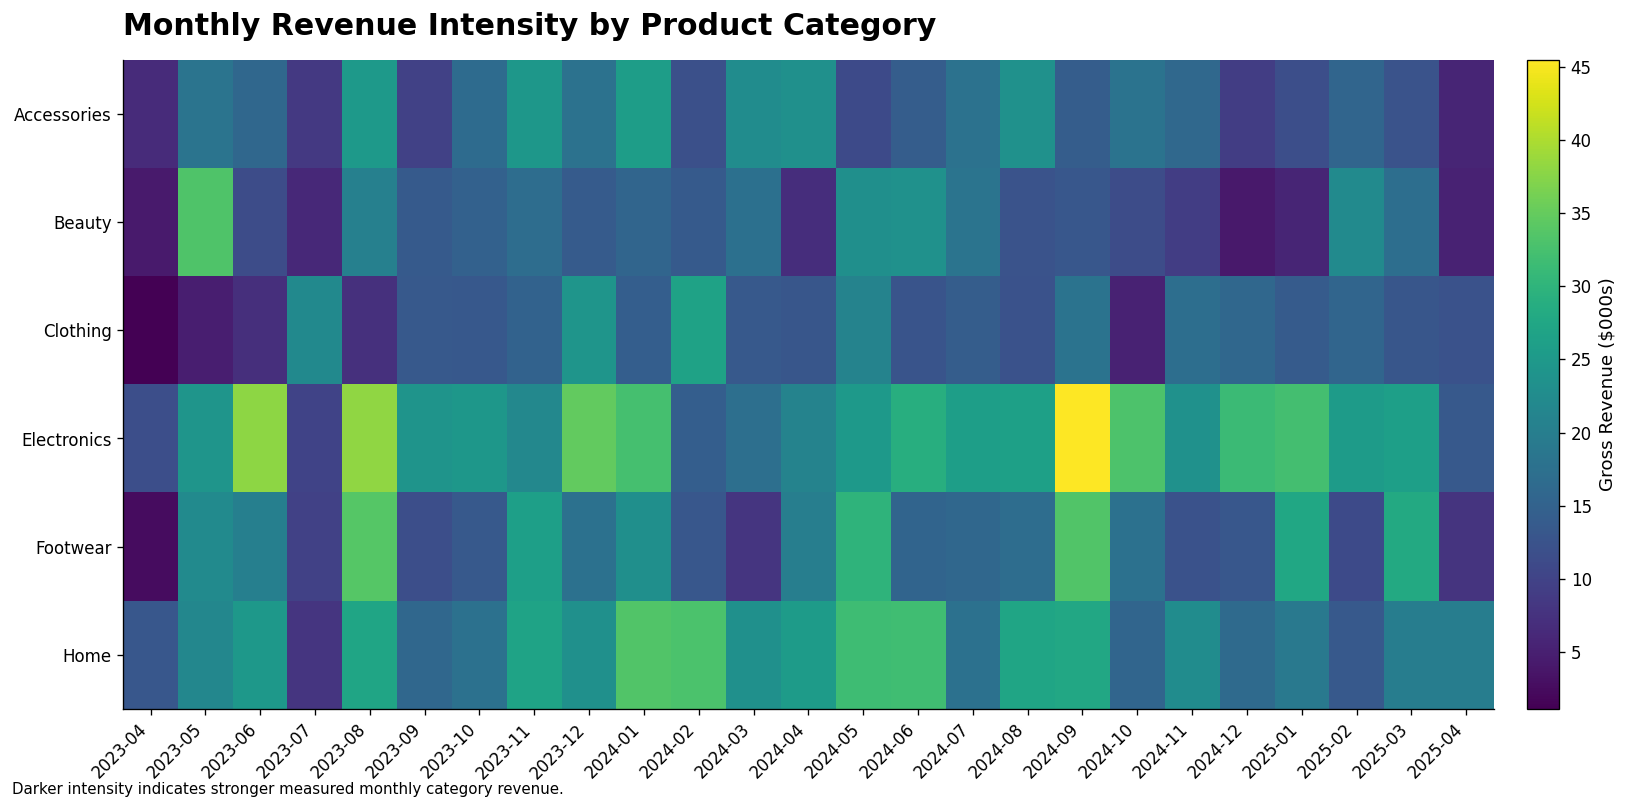

✓ Saved: /content/ecommerce_presentation/charts/15_return_risk_matrix.png


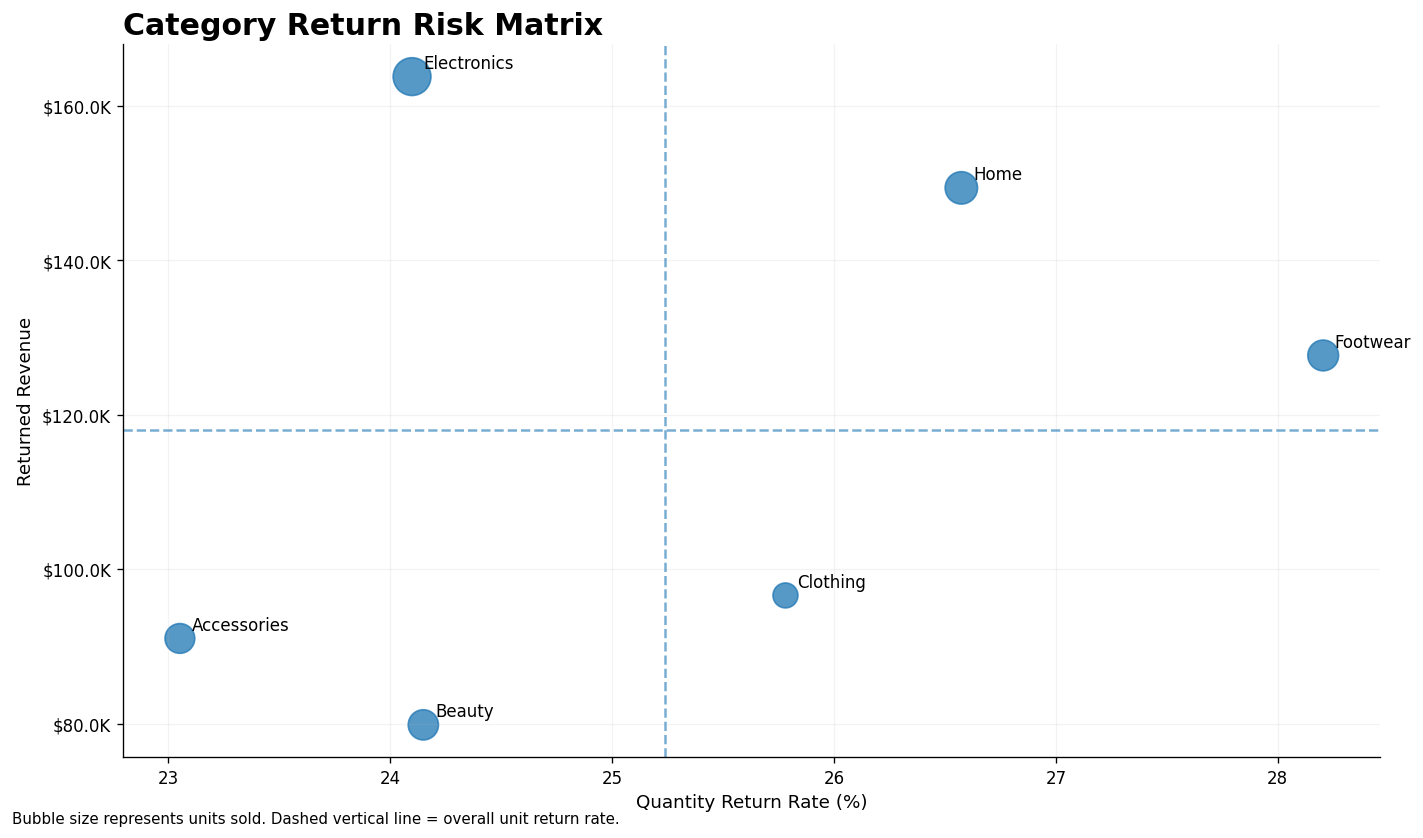

✓ Saved: /content/ecommerce_presentation/charts/16_executive_kpi_dashboard.png


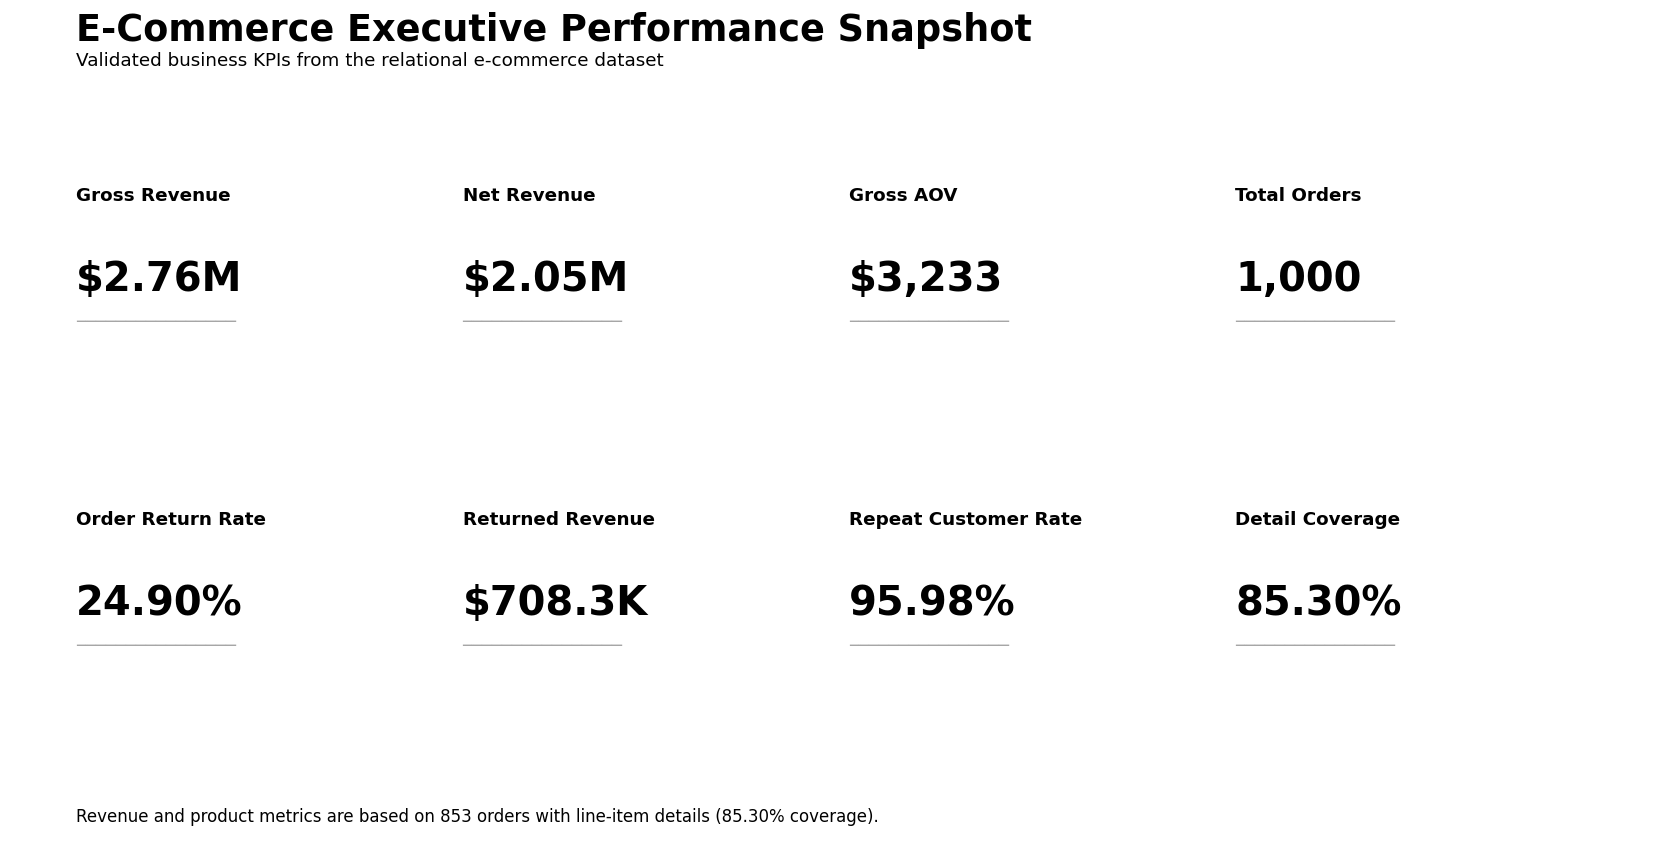

✓ Saved: /content/ecommerce_presentation/charts/17_revenue_vs_returns_summary.png


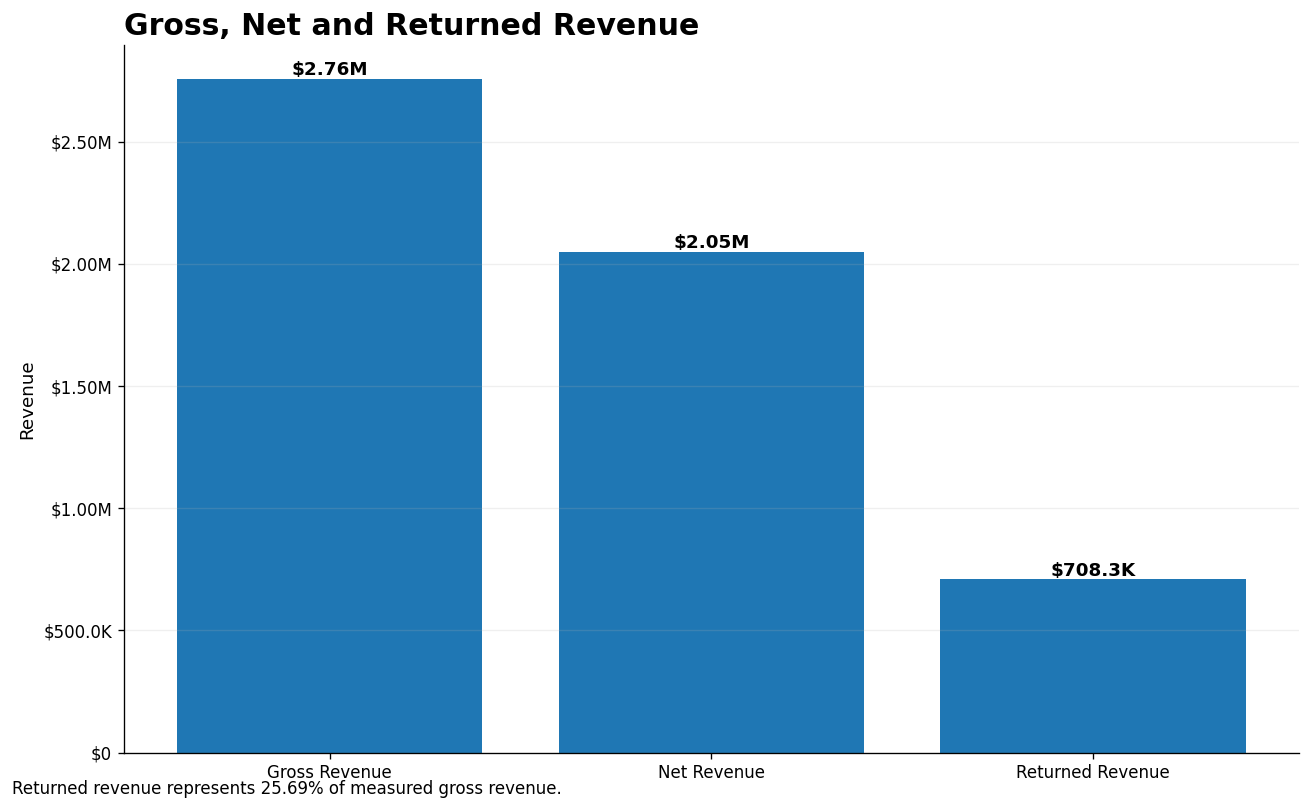


STAGE 4D VALIDATION
PASS | Heatmap contains 25 calendar months
PASS | Heatmap contains 6 product categories
PASS | Heatmap revenue reconciles to gross revenue
PASS | Return-risk matrix contains 6 categories
PASS | Risk-matrix returned revenue reconciles
PASS | Executive revenue summary validated
PASS | Eight executive insights created
------------------------------------------------------------------------
RESULT: 7/7 checks passed

✓ STAGE 4D COMPLETE — executive presentation assets validated.


In [11]:
# ============================================================
# STAGE 4D — EXECUTIVE PRESENTATION VISUALS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ============================================================
# CHART 14 — CATEGORY × MONTH REVENUE HEATMAP
# ============================================================

heatmap_data = (
    sales
    .assign(
        Month=sales["OrderDate"].dt.to_period("M")
    )
    .groupby(
        ["Category", "Month"],
        as_index=False
    )
    .agg(
        GrossRevenue=("LineRevenue", "sum")
    )
)

heatmap_pivot = (
    heatmap_data
    .pivot(
        index="Category",
        columns="Month",
        values="GrossRevenue"
    )
    .fillna(0)
)

heatmap_pivot.to_csv(
    TABLE_DIR / "category_monthly_revenue_heatmap.csv"
)

# Convert values to $000s for cleaner display
heatmap_k = heatmap_pivot / 1000

fig, ax = plt.subplots(figsize=(15, 6.75))

image = ax.imshow(
    heatmap_k.values,
    aspect="auto"
)

ax.set_title(
    "Monthly Revenue Intensity by Product Category",
    loc="left",
    fontweight="bold",
    fontsize=18,
    pad=15
)

ax.set_yticks(
    np.arange(len(heatmap_k.index))
)

ax.set_yticklabels(
    heatmap_k.index
)

month_labels = [
    str(month)
    for month in heatmap_k.columns
]

ax.set_xticks(
    np.arange(len(month_labels))
)

ax.set_xticklabels(
    month_labels,
    rotation=45,
    ha="right"
)

ax.set_xlabel("")
ax.set_ylabel("")

colorbar = fig.colorbar(
    image,
    ax=ax,
    pad=0.02
)

colorbar.set_label(
    "Gross Revenue ($000s)"
)

fig.text(
    0.01,
    0.01,
    (
        "Darker intensity indicates stronger measured "
        "monthly category revenue."
    ),
    fontsize=9
)

save_chart("14_category_monthly_heatmap.png")


# ============================================================
# CHART 15 — CATEGORY RETURN RISK MATRIX
# ============================================================

risk_matrix = (
    category_returns[
        [
            "Category",
            "UnitsSold",
            "ReturnedUnits",
            "ReturnedRevenue",
            "QuantityReturnRatePct"
        ]
    ]
    .copy()
)

risk_matrix.to_csv(
    TABLE_DIR / "category_return_risk_matrix.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    risk_matrix["QuantityReturnRatePct"],
    risk_matrix["ReturnedRevenue"],
    s=np.maximum(
        risk_matrix["UnitsSold"].to_numpy() * 0.35,
        80
    ),
    alpha=0.75
)

for _, row in risk_matrix.iterrows():

    ax.annotate(
        row["Category"],
        (
            row["QuantityReturnRatePct"],
            row["ReturnedRevenue"]
        ),
        xytext=(7, 5),
        textcoords="offset points",
        fontsize=10
    )

ax.axvline(
    unit_return_rate,
    linestyle="--",
    linewidth=1.5,
    alpha=0.6
)

ax.axhline(
    risk_matrix["ReturnedRevenue"].mean(),
    linestyle="--",
    linewidth=1.5,
    alpha=0.6
)

ax.set_title(
    "Category Return Risk Matrix",
    loc="left",
    fontweight="bold"
)

ax.set_xlabel("Quantity Return Rate (%)")
ax.set_ylabel("Returned Revenue")

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: money_short(x)
    )
)

ax.grid(
    alpha=0.15
)

fig.text(
    0.01,
    0.01,
    (
        "Bubble size represents units sold. "
        "Dashed vertical line = overall unit return rate."
    ),
    fontsize=9
)

save_chart("15_return_risk_matrix.png")


# ============================================================
# CHART 16 — EXECUTIVE KPI DASHBOARD
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7.5))

ax.axis("off")

fig.suptitle(
    "E-Commerce Executive Performance Snapshot",
    fontsize=22,
    fontweight="bold",
    x=0.05,
    ha="left",
    y=0.96
)

fig.text(
    0.05,
    0.90,
    (
        "Validated business KPIs from the relational "
        "e-commerce dataset"
    ),
    fontsize=11
)

kpi_cards = [
    (
        "Gross Revenue",
        f"${gross_revenue / 1_000_000:.2f}M"
    ),
    (
        "Net Revenue",
        f"${net_revenue / 1_000_000:.2f}M"
    ),
    (
        "Gross AOV",
        f"${gross_aov:,.0f}"
    ),
    (
        "Total Orders",
        f"{total_orders:,}"
    ),
    (
        "Order Return Rate",
        f"{overall_return_rate:.2f}%"
    ),
    (
        "Returned Revenue",
        f"${returned_revenue / 1000:.1f}K"
    ),
    (
        "Repeat Customer Rate",
        f"{repeat_customer_rate:.2f}%"
    ),
    (
        "Detail Coverage",
        f"{detail_coverage:.2f}%"
    ),
]

positions = [
    (0.05, 0.61),
    (0.28, 0.61),
    (0.51, 0.61),
    (0.74, 0.61),
    (0.05, 0.25),
    (0.28, 0.25),
    (0.51, 0.25),
    (0.74, 0.25),
]

for (title, value), (x, y) in zip(
    kpi_cards,
    positions
):

    fig.text(
        x,
        y + 0.14,
        title,
        fontsize=11,
        fontweight="bold"
    )

    fig.text(
        x,
        y + 0.04,
        value,
        fontsize=24,
        fontweight="bold"
    )

    fig.text(
        x,
        y,
        "────────────────",
        fontsize=10,
        alpha=0.35
    )

fig.text(
    0.05,
    0.06,
    (
        "Revenue and product metrics are based on "
        f"{orders_with_details:,} orders with line-item details "
        f"({detail_coverage:.2f}% coverage)."
    ),
    fontsize=10
)

save_chart("16_executive_kpi_dashboard.png")


# ============================================================
# CHART 17 — GROSS VS NET VS RETURNED REVENUE
# ============================================================

revenue_summary = pd.DataFrame({
    "Metric": [
        "Gross Revenue",
        "Net Revenue",
        "Returned Revenue"
    ],
    "Revenue": [
        gross_revenue,
        net_revenue,
        returned_revenue
    ]
})

revenue_summary.to_csv(
    TABLE_DIR / "revenue_summary.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(11, 6.75))

bars = ax.bar(
    revenue_summary["Metric"],
    revenue_summary["Revenue"]
)

ax.set_title(
    "Gross, Net and Returned Revenue",
    loc="left",
    fontweight="bold"
)

ax.set_ylabel("Revenue")
ax.set_xlabel("")

ax.grid(
    axis="y",
    alpha=0.20
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: money_short(x)
    )
)

for bar, value in zip(
    bars,
    revenue_summary["Revenue"]
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        money_short(value),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

fig.text(
    0.01,
    0.01,
    (
        f"Returned revenue represents "
        f"{returned_revenue_share:.2f}% "
        "of measured gross revenue."
    ),
    fontsize=10
)

save_chart("17_revenue_vs_returns_summary.png")


# ============================================================
# STAGE 4D — EXECUTIVE INSIGHTS TABLE
# ============================================================

executive_insights = pd.DataFrame({

    "Area": [
        "Revenue",
        "Returns",
        "Category",
        "Region",
        "Customer",
        "Product",
        "Return Risk",
        "Data Quality"
    ],

    "Finding": [
        f"Measured gross revenue reached "
        f"${gross_revenue / 1_000_000:.2f}M.",

        f"${returned_revenue / 1000:.1f}K of measured "
        f"revenue is associated with returned orders.",

        "Electronics generated the highest measured "
        "category revenue.",

        "Asia East (Japan) generated the highest "
        "measured regional revenue.",

        f"Repeat customers represent "
        f"{repeat_customer_rate:.2f}% of active customers.",

        "Smartphone M (#64) generated the highest "
        "measured product revenue.",

        "Footwear has the highest quantity return rate, "
        "while Electronics has the greatest returned-"
        "revenue exposure.",

        f"{orders_with_details:,} of {total_orders:,} orders "
        "contain line-item details."
    ],

    "BusinessImplication": [
        "Protect and grow the strongest revenue drivers.",

        "Returns represent a material financial exposure "
        "and should be actively investigated.",

        "Prioritize high-performing categories while "
        "monitoring assortment effects.",

        "Use regional differences to guide commercial "
        "and retention strategies.",

        "Retention appears exceptionally high in this "
        "synthetic dataset; interpret cautiously.",

        "Protect availability and investigate the factors "
        "driving performance of leading products.",

        "Return-rate and financial exposure should be "
        "managed as separate risk measures.",

        "Improve transaction-detail completeness before "
        "using monetary metrics for full-order reporting."
    ]
})

executive_insights.to_csv(
    TABLE_DIR / "executive_insights.csv",
    index=False
)


# ============================================================
# STAGE 4D VALIDATION
# ============================================================

print("\n" + "=" * 72)
print("STAGE 4D VALIDATION")
print("=" * 72)

checks = [

    (
        heatmap_pivot.shape[1] == 25,
        "Heatmap contains 25 calendar months"
    ),

    (
        heatmap_pivot.shape[0] == 6,
        "Heatmap contains 6 product categories"
    ),

    (
        abs(
            heatmap_pivot.to_numpy().sum()
            - gross_revenue
        ) < 0.01,
        "Heatmap revenue reconciles to gross revenue"
    ),

    (
        len(risk_matrix) == 6,
        "Return-risk matrix contains 6 categories"
    ),

    (
        abs(
            risk_matrix["ReturnedRevenue"].sum()
            - returned_revenue
        ) < 0.01,
        "Risk-matrix returned revenue reconciles"
    ),

    (
        abs(
            revenue_summary.loc[
                revenue_summary["Metric"]
                == "Gross Revenue",
                "Revenue"
            ].iloc[0]
            - gross_revenue
        ) < 0.01,
        "Executive revenue summary validated"
    ),

    (
        len(executive_insights) == 8,
        "Eight executive insights created"
    ),

]

passed = 0

for status, description in checks:

    if status:
        print(f"PASS | {description}")
        passed += 1

    else:
        print(f"FAIL | {description}")

print("-" * 72)

print(
    f"RESULT: {passed}/{len(checks)} checks passed"
)

if passed == len(checks):

    print(
        "\n✓ STAGE 4D COMPLETE — "
        "executive presentation assets validated."
    )

else:

    print(
        "\n⚠ Stop before PowerPoint generation."
    )

## Stage 4E — Automated PowerPoint Generation

This stage converts the validated analytical outputs into a professional
12-slide executive PowerPoint presentation.

The presentation uses only previously validated KPIs and chart assets.

In [12]:
# ============================================================
# STAGE 4E-1 — POWERPOINT ENGINE + DESIGN SYSTEM
# ============================================================

!pip -q install python-pptx

from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN, MSO_ANCHOR
from pptx.enum.shapes import MSO_SHAPE
from pathlib import Path
import os


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PPT_DIR = OUTPUT_DIR / "presentation"
PPT_DIR.mkdir(parents=True, exist_ok=True)

PPT_PATH = PPT_DIR / "Ecommerce_SQL_Analytics_Presentation.pptx"


# ------------------------------------------------------------
# PRESENTATION
# ------------------------------------------------------------

prs = Presentation()

prs.slide_width = Inches(13.333)
prs.slide_height = Inches(7.5)


# ------------------------------------------------------------
# EXECUTIVE THEME
# ------------------------------------------------------------

NAVY = RGBColor(15, 35, 58)
TEAL = RGBColor(15, 118, 110)
DARK_TEAL = RGBColor(13, 88, 82)

WHITE = RGBColor(255, 255, 255)
OFF_WHITE = RGBColor(247, 249, 251)

DARK_TEXT = RGBColor(32, 44, 57)
MID_TEXT = RGBColor(90, 105, 120)
LIGHT_TEXT = RGBColor(205, 215, 225)

LIGHT_BLUE = RGBColor(232, 241, 246)
LIGHT_TEAL = RGBColor(229, 244, 242)

BORDER = RGBColor(220, 226, 232)

RED = RGBColor(183, 67, 67)
GREEN = RGBColor(45, 125, 95)
GOLD = RGBColor(176, 132, 45)


# ------------------------------------------------------------
# BASIC HELPERS
# ------------------------------------------------------------

def set_background(slide, color=WHITE):

    background = slide.background
    fill = background.fill

    fill.solid()
    fill.fore_color.rgb = color


def add_text(
    slide,
    text,
    x,
    y,
    w,
    h,
    font_size=18,
    color=DARK_TEXT,
    bold=False,
    font_name="Aptos",
    align=PP_ALIGN.LEFT,
    valign=MSO_ANCHOR.TOP
):

    box = slide.shapes.add_textbox(
        Inches(x),
        Inches(y),
        Inches(w),
        Inches(h)
    )

    frame = box.text_frame

    frame.clear()
    frame.word_wrap = True
    frame.vertical_anchor = valign

    paragraph = frame.paragraphs[0]

    paragraph.text = str(text)
    paragraph.alignment = align

    run = paragraph.runs[0]

    run.font.name = font_name
    run.font.size = Pt(font_size)
    run.font.bold = bold
    run.font.color.rgb = color

    return box


def add_title(slide, title, subtitle=None):

    add_text(
        slide,
        title,
        0.65,
        0.38,
        11.9,
        0.55,
        font_size=25,
        color=NAVY,
        bold=True
    )

    # teal accent
    shape = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE,
        Inches(0.65),
        Inches(1.02),
        Inches(0.72),
        Inches(0.06)
    )

    shape.fill.solid()
    shape.fill.fore_color.rgb = TEAL
    shape.line.fill.background()

    if subtitle:

        add_text(
            slide,
            subtitle,
            0.65,
            1.13,
            11.9,
            0.4,
            font_size=10,
            color=MID_TEXT
        )


def add_footer(slide, slide_number):

    # footer divider
    line = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE,
        Inches(0.65),
        Inches(7.13),
        Inches(12.0),
        Inches(0.012)
    )

    line.fill.solid()
    line.fill.fore_color.rgb = BORDER
    line.line.fill.background()

    add_text(
        slide,
        "E-Commerce Sales & Customer Intelligence Using SQL",
        0.65,
        7.18,
        7.5,
        0.18,
        font_size=7,
        color=MID_TEXT
    )

    add_text(
        slide,
        str(slide_number),
        12.05,
        7.16,
        0.55,
        0.2,
        font_size=8,
        color=MID_TEXT,
        align=PP_ALIGN.RIGHT
    )


def add_kpi_card(
    slide,
    title,
    value,
    x,
    y,
    w=2.75,
    h=1.25,
    accent=TEAL
):

    card = slide.shapes.add_shape(
        MSO_SHAPE.ROUNDED_RECTANGLE,
        Inches(x),
        Inches(y),
        Inches(w),
        Inches(h)
    )

    card.fill.solid()
    card.fill.fore_color.rgb = OFF_WHITE

    card.line.color.rgb = BORDER

    accent_bar = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE,
        Inches(x),
        Inches(y),
        Inches(0.07),
        Inches(h)
    )

    accent_bar.fill.solid()
    accent_bar.fill.fore_color.rgb = accent
    accent_bar.line.fill.background()

    add_text(
        slide,
        title,
        x + 0.22,
        y + 0.18,
        w - 0.35,
        0.3,
        font_size=9,
        color=MID_TEXT,
        bold=True
    )

    add_text(
        slide,
        value,
        x + 0.22,
        y + 0.53,
        w - 0.35,
        0.5,
        font_size=21,
        color=NAVY,
        bold=True
    )


def add_insight_box(
    slide,
    heading,
    text,
    x,
    y,
    w,
    h,
    accent=TEAL
):

    box = slide.shapes.add_shape(
        MSO_SHAPE.ROUNDED_RECTANGLE,
        Inches(x),
        Inches(y),
        Inches(w),
        Inches(h)
    )

    box.fill.solid()
    box.fill.fore_color.rgb = OFF_WHITE
    box.line.color.rgb = BORDER

    add_text(
        slide,
        heading,
        x + 0.22,
        y + 0.16,
        w - 0.44,
        0.28,
        font_size=10,
        color=accent,
        bold=True
    )

    add_text(
        slide,
        text,
        x + 0.22,
        y + 0.52,
        w - 0.44,
        h - 0.65,
        font_size=10,
        color=DARK_TEXT
    )


def add_bullets(
    slide,
    items,
    x,
    y,
    w,
    h,
    font_size=15,
    color=DARK_TEXT
):

    box = slide.shapes.add_textbox(
        Inches(x),
        Inches(y),
        Inches(w),
        Inches(h)
    )

    tf = box.text_frame
    tf.clear()
    tf.word_wrap = True

    for i, item in enumerate(items):

        p = (
            tf.paragraphs[0]
            if i == 0
            else tf.add_paragraph()
        )

        p.text = item
        p.level = 0
        p.font.name = "Aptos"
        p.font.size = Pt(font_size)
        p.font.color.rgb = color
        p.space_after = Pt(10)
        p.text = "• " + item

    return box


def add_chart_image(
    slide,
    filename,
    x,
    y,
    w,
    h=None
):

    path = CHART_DIR / filename

    if not path.exists():
        raise FileNotFoundError(
            f"Chart not found: {path}"
        )

    if h is None:

        slide.shapes.add_picture(
            str(path),
            Inches(x),
            Inches(y),
            width=Inches(w)
        )

    else:

        slide.shapes.add_picture(
            str(path),
            Inches(x),
            Inches(y),
            width=Inches(w),
            height=Inches(h)
        )


def add_section_label(
    slide,
    text,
    x,
    y,
    w=2.1
):

    shape = slide.shapes.add_shape(
        MSO_SHAPE.ROUNDED_RECTANGLE,
        Inches(x),
        Inches(y),
        Inches(w),
        Inches(0.35)
    )

    shape.fill.solid()
    shape.fill.fore_color.rgb = LIGHT_TEAL

    shape.line.fill.background()

    add_text(
        slide,
        text.upper(),
        x + 0.12,
        y + 0.075,
        w - 0.24,
        0.18,
        font_size=7,
        color=DARK_TEAL,
        bold=True
    )


# ------------------------------------------------------------
# BLANK SLIDE LAYOUT
# ------------------------------------------------------------

blank_layout = prs.slide_layouts[6]


print("=" * 72)
print("STAGE 4E-1 — POWERPOINT ENGINE")
print("=" * 72)

print("✓ python-pptx ready")
print("✓ 16:9 presentation initialized")
print("✓ Executive theme initialized")
print("✓ PowerPoint helper functions created")
print(f"✓ Output: {PPT_PATH}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.7 MB/s eta 0:00:00
STAGE 4E-1 — POWERPOINT ENGINE
✓ python-pptx ready
✓ 16:9 presentation initialized
✓ Executive theme initialized
✓ PowerPoint helper functions created
✓ Output: /content/ecommerce_presentation/presentation/Ecommerce_SQL_Analytics_Presentation.pptx


In [13]:
# ============================================================
# STAGE 4E-2 — BUILD 12-SLIDE EXECUTIVE PRESENTATION
# ============================================================


# ============================================================
# SLIDE 1 — TITLE
# ============================================================

slide = prs.slides.add_slide(blank_layout)

set_background(slide, NAVY)

# Accent
shape = slide.shapes.add_shape(
    MSO_SHAPE.RECTANGLE,
    Inches(0.75),
    Inches(1.10),
    Inches(0.10),
    Inches(4.70)
)

shape.fill.solid()
shape.fill.fore_color.rgb = TEAL
shape.line.fill.background()

add_text(
    slide,
    "E-COMMERCE",
    1.15,
    1.25,
    4.5,
    0.4,
    font_size=12,
    color=TEAL,
    bold=True
)

add_text(
    slide,
    "Sales & Customer\nIntelligence Using SQL",
    1.15,
    1.78,
    10.6,
    1.7,
    font_size=34,
    color=WHITE,
    bold=True
)

add_text(
    slide,
    (
        "Revenue • Customer Behaviour • Products • "
        "Regions • Returns"
    ),
    1.15,
    3.72,
    10.6,
    0.45,
    font_size=15,
    color=LIGHT_TEXT
)

add_text(
    slide,
    "MySQL 8  |  Python  |  Google Colab  |  Business Analytics",
    1.15,
    4.35,
    10.5,
    0.35,
    font_size=11,
    color=WHITE
)

add_text(
    slide,
    "Portfolio Analytics Project",
    1.15,
    5.55,
    4.0,
    0.3,
    font_size=10,
    color=TEAL,
    bold=True
)

add_text(
    slide,
    "Sombir Singh",
    1.15,
    5.95,
    4.5,
    0.35,
    font_size=15,
    color=WHITE,
    bold=True
)


# ============================================================
# SLIDE 2 — BUSINESS PROBLEM
# ============================================================

slide = prs.slides.add_slide(blank_layout)

set_background(slide)

add_title(
    slide,
    "Business Problem & Analytical Objectives",
    "Turning relational transaction data into actionable commercial intelligence"
)

add_section_label(
    slide,
    "Business Questions",
    0.7,
    1.65
)

add_bullets(
    slide,
    [
        "How much measurable revenue is the business generating?",
        "Which categories, products and regions drive commercial performance?",
        "Which customers contribute the greatest historical value?",
        "How frequently do customers purchase and return?",
        "Where is return-related financial exposure concentrated?"
    ],
    0.8,
    2.12,
    5.65,
    3.9,
    font_size=14
)

add_section_label(
    slide,
    "Analytical Approach",
    7.0,
    1.65
)

add_bullets(
    slide,
    [
        "Relational analysis across Customers, Orders, OrderDetails, Products and Regions",
        "25 validated SQL business analyses",
        "CTEs, joins, conditional aggregation and window functions",
        "Independent Python reconciliation of presentation KPIs",
        "Executive visualization and business recommendation layer"
    ],
    7.1,
    2.12,
    5.35,
    3.9,
    font_size=14
)

add_footer(slide, 2)


# ============================================================
# SLIDE 3 — DATABASE + DATA QUALITY
# ============================================================

slide = prs.slides.add_slide(blank_layout)

set_background(slide)

add_title(
    slide,
    "Database Architecture & Data Quality",
    "Revenue metrics require available line-item details"
)

# relationship flow
entities = [
    ("Regions", "10"),
    ("Customers", "200"),
    ("Orders", "1,000"),
    ("OrderDetails", "2,000"),
    ("Products", "100")
]

x_positions = [
    0.65,
    3.18,
    5.71,
    8.24,
    10.77
]

for (name, count), x in zip(
    entities,
    x_positions
):

    card = slide.shapes.add_shape(
        MSO_SHAPE.ROUNDED_RECTANGLE,
        Inches(x),
        Inches(1.8),
        Inches(1.9),
        Inches(1.15)
    )

    card.fill.solid()
    card.fill.fore_color.rgb = OFF_WHITE
    card.line.color.rgb = BORDER

    add_text(
        slide,
        name,
        x + 0.12,
        2.02,
        1.66,
        0.25,
        font_size=11,
        color=NAVY,
        bold=True,
        align=PP_ALIGN.CENTER
    )

    add_text(
        slide,
        count,
        x + 0.12,
        2.39,
        1.66,
        0.3,
        font_size=16,
        color=TEAL,
        bold=True,
        align=PP_ALIGN.CENTER
    )

# arrows
for x in [2.64, 5.17, 7.70, 10.23]:

    add_text(
        slide,
        "→",
        x,
        2.13,
        0.4,
        0.3,
        font_size=19,
        color=TEAL,
        bold=True,
        align=PP_ALIGN.CENTER
    )

add_kpi_card(
    slide,
    "TOTAL ORDERS",
    "1,000",
    0.85,
    3.55,
    2.7,
    1.2
)

add_kpi_card(
    slide,
    "ORDERS WITH DETAILS",
    "853",
    3.75,
    3.55,
    2.7,
    1.2
)

add_kpi_card(
    slide,
    "MISSING DETAILS",
    "147",
    6.65,
    3.55,
    2.7,
    1.2,
    accent=GOLD
)

add_kpi_card(
    slide,
    "DETAIL COVERAGE",
    "85.30%",
    9.55,
    3.55,
    2.7,
    1.2
)

add_insight_box(
    slide,
    "IMPORTANT METHODOLOGICAL NOTE",
    (
        "Order-level metrics use all 1,000 orders. "
        "Revenue, AOV, product and unit-based metrics use the "
        "853 orders with available OrderDetails. This distinction "
        "prevents incomplete transactions from being treated as "
        "zero-revenue orders."
    ),
    0.85,
    5.15,
    11.4,
    1.25,
    accent=GOLD
)

add_footer(slide, 3)


# ============================================================
# SLIDE 4 — EXECUTIVE KPI DASHBOARD
# ============================================================

slide = prs.slides.add_slide(blank_layout)

set_background(slide)

add_title(
    slide,
    "Executive Performance Snapshot",
    "Core validated commercial and customer KPIs"
)

add_kpi_card(
    slide,
    "GROSS REVENUE",
    "$2.76M",
    0.75,
    1.65
)

add_kpi_card(
    slide,
    "NET REVENUE",
    "$2.05M",
    3.80,
    1.65
)

add_kpi_card(
    slide,
    "GROSS AOV",
    "$3,233",
    6.85,
    1.65
)

add_kpi_card(
    slide,
    "TOTAL ORDERS",
    "1,000",
    9.90,
    1.65
)

add_kpi_card(
    slide,
    "RETURN RATE",
    "24.90%",
    0.75,
    3.25,
    accent=RED
)

add_kpi_card(
    slide,
    "RETURNED REVENUE",
    "$708.3K",
    3.80,
    3.25,
    accent=RED
)

add_kpi_card(
    slide,
    "REPEAT RATE",
    "95.98%",
    6.85,
    3.25,
    accent=GREEN
)

add_kpi_card(
    slide,
    "DETAIL COVERAGE",
    "85.30%",
    9.90,
    3.25,
    accent=GOLD
)

add_insight_box(
    slide,
    "EXECUTIVE READOUT",
    (
        "Measured gross revenue reaches $2.76M, but $708.3K "
        "(25.69%) is associated with returned orders. "
        "Returns therefore represent one of the clearest areas "
        "for commercial investigation."
    ),
    0.75,
    5.15,
    12.0,
    1.05,
    accent=RED
)

add_footer(slide, 4)


# ============================================================
# SLIDE 5 — REVENUE PERFORMANCE
# ============================================================

slide = prs.slides.add_slide(blank_layout)

set_background(slide)

add_title(
    slide,
    "Revenue Performance Over Time",
    "Monthly measured gross revenue across the available transaction period"
)

add_chart_image(
    slide,
    "01_monthly_revenue_trend.png",
    0.65,
    1.55,
    8.15,
    4.75
)

add_insight_box(
    slide,
    "PEAK MONTH",
    "September 2024 generated the highest observed monthly gross revenue: $151.9K.",
    9.15,
    1.75,
    3.45,
    1.35
)

add_insight_box(
    slide,
    "2024 PERFORMANCE",
    "2024 generated $1.412M measured gross revenue and is the only full calendar year in the dataset.",
    9.15,
    3.30,
    3.45,
    1.55
)

add_insight_box(
    slide,
    "INTERPRETATION",
    "2023 begins in April and 2025 ends in April, so annual totals should not be treated as directly comparable full-year growth.",
    9.15,
    5.05,
    3.45,
    1.35,
    accent=GOLD
)

add_footer(slide, 5)


# ============================================================
# SLIDE 6 — CATEGORY PERFORMANCE
# ============================================================

slide = prs.slides.add_slide(blank_layout)

set_background(slide)

add_title(
    slide,
    "Category Performance",
    "Revenue concentration and category contribution"
)

add_chart_image(
    slide,
    "02_revenue_by_category.png",
    0.65,
    1.55,
    7.45,
    4.9
)

add_insight_box(
    slide,
    "LEADING CATEGORY",
    "Electronics generated $649.4K, representing 23.55% of measured gross revenue.",
    8.45,
    1.75,
    4.05,
    1.25
)

add_insight_box(
    slide,
    "SECOND-LARGEST CATEGORY",
    "Home generated $557.4K, representing 20.21% of measured gross revenue.",
    8.45,
    3.20,
    4.05,
    1.25
)

add_insight_box(
    slide,
    "CONCENTRATION",
    "Electronics + Home contributed approximately 43.76% of measured gross revenue.",
    8.45,
    4.65,
    4.05,
    1.25
)

add_text(
    slide,
    (
        "Note: Electronics contains more products than several other "
        "categories, so revenue leadership should not automatically "
        "be interpreted as superior per-product productivity."
    ),
    8.48,
    6.08,
    3.95,
    0.55,
    font_size=8,
    color=MID_TEXT
)

add_footer(slide, 6)


# ============================================================
# SLIDE 7 — CUSTOMER INTELLIGENCE
# ============================================================

slide = prs.slides.add_slide(blank_layout)

set_background(slide)

add_title(
    slide,
    "Customer Intelligence",
    "Historical customer value, retention and segmentation"
)

add_chart_image(
    slide,
    "05_top_10_customers.png",
    0.65,
    1.55,
    7.35,
    4.9
)

add_kpi_card(
    slide,
    "ACTIVE CUSTOMERS",
    "199",
    8.35,
    1.70,
    1.95,
    1.15
)

add_kpi_card(
    slide,
    "REPEAT CUSTOMERS",
    "191",
    10.55,
    1.70,
    1.95,
    1.15,
    accent=GREEN
)

add_insight_box(
    slide,
    "TOP HISTORICAL VALUE",
    (
        "Melanie Davis generated $46,959.01 measured gross "
        "revenue across 6 revenue-bearing orders."
    ),
    8.35,
    3.20,
    4.15,
    1.35
)

add_insight_box(
    slide,
    "RETENTION SIGNAL",
    (
        "95.98% of active customers placed more than one order. "
        "Because the dataset is synthetic, this unusually high "
        "repeat rate should be interpreted cautiously."
    ),
    8.35,
    4.75,
    4.15,
    1.55,
    accent=GOLD
)

add_footer(slide, 7)


# ============================================================
# SLIDE 8 — PRODUCT PERFORMANCE
# ============================================================

slide = prs.slides.add_slide(blank_layout)

set_background(slide)

add_title(
    slide,
    "Product Performance",
    "Top products ranked by measured gross revenue"
)

add_chart_image(
    slide,
    "04_top_10_products_revenue.png",
    0.65,
    1.55,
    8.05,
    4.95
)

add_insight_box(
    slide,
    "TOP PRODUCT",
    "Smartphone M (#64) generated $93,856 in measured gross revenue.",
    9.05,
    1.75,
    3.5,
    1.25
)

add_insight_box(
    slide,
    "VOLUME LEADER",
    "Smartphone M (#64) also sold 100 units, making it the highest-volume product.",
    9.05,
    3.25,
    3.5,
    1.35
)

add_insight_box(
    slide,
    "DATA MODEL NOTE",
    (
        "Product names are not unique in the dataset. "
        "ProductID is therefore retained when ranking products."
    ),
    9.05,
    4.85,
    3.5,
    1.35,
    accent=GOLD
)

add_footer(slide, 8)


# ============================================================
# SLIDE 9 — REGIONAL PERFORMANCE
# ============================================================

slide = prs.slides.add_slide(blank_layout)

set_background(slide)

add_title(
    slide,
    "Regional Performance",
    "Measured revenue contribution across geographic markets"
)

add_chart_image(
    slide,
    "03_revenue_by_region.png",
    0.65,
    1.55,
    8.05,
    4.95
)

add_insight_box(
    slide,
    "REVENUE LEADER",
    "Asia East / Japan generated the highest measured regional revenue at $422.3K.",
    9.05,
    1.75,
    3.5,
    1.35
)

add_insight_box(
    slide,
    "HIGHEST AOV",
    "Africa North / Egypt recorded the highest regional gross AOV at $3,654.24.",
    9.05,
    3.35,
    3.5,
    1.35
)

add_insight_box(
    slide,
    "PURCHASE MIX",
    (
        "Europe Central / Germany recorded the highest weighted "
        "average purchased unit price at $491.08."
    ),
    9.05,
    4.95,
    3.5,
    1.35
)

add_footer(slide, 9)


# ============================================================
# SLIDE 10 — RETURN RISK
# ============================================================

slide = prs.slides.add_slide(blank_layout)

set_background(slide)

add_title(
    slide,
    "Returns & Commercial Risk",
    "Return frequency and financial exposure reveal different risk signals"
)

add_chart_image(
    slide,
    "15_return_risk_matrix.png",
    0.55,
    1.55,
    7.55,
    4.85
)

add_kpi_card(
    slide,
    "ORDER RETURN RATE",
    "24.90%",
    8.45,
    1.70,
    1.95,
    1.15,
    accent=RED
)

add_kpi_card(
    slide,
    "RETURNED REVENUE",
    "$708.3K",
    10.65,
    1.70,
    1.95,
    1.15,
    accent=RED
)

add_insight_box(
    slide,
    "RATE RISK",
    "Footwear has the highest quantity return rate at 28.21%.",
    8.45,
    3.15,
    4.15,
    1.05,
    accent=RED
)

add_insight_box(
    slide,
    "FINANCIAL EXPOSURE",
    "Electronics has the greatest returned-revenue exposure at $163.8K.",
    8.45,
    4.40,
    4.15,
    1.05,
    accent=RED
)

add_insight_box(
    slide,
    "REGIONAL RISK",
    "Africa South / South Africa has the highest regional order return rate at 31.37%.",
    8.45,
    5.65,
    4.15,
    1.05,
    accent=RED
)

add_footer(slide, 10)


# ============================================================
# SLIDE 11 — RECOMMENDATIONS
# ============================================================

slide = prs.slides.add_slide(blank_layout)

set_background(slide)

add_title(
    slide,
    "Key Insights & Business Recommendations",
    "Translating analytical findings into practical actions"
)

recommendations = [
    (
        "01",
        "Reduce return exposure",
        (
            "Investigate Footwear return drivers and high-value "
            "Electronics returns separately because frequency and "
            "financial exposure represent different risks."
        )
    ),
    (
        "02",
        "Protect revenue leaders",
        (
            "Prioritize availability and commercial monitoring for "
            "leading categories and high-performing products."
        )
    ),
    (
        "03",
        "Use regional targeting",
        (
            "Study the behaviours behind Asia East's revenue leadership, "
            "Africa North's high AOV and Africa South's elevated returns."
        )
    ),
    (
        "04",
        "Improve customer segmentation",
        (
            "Replace the assignment's fixed spend thresholds with "
            "percentile or RFM-based segmentation for more actionable groups."
        )
    ),
    (
        "05",
        "Improve data completeness",
        (
            "Resolve the 147 orders without OrderDetails before using "
            "monetary metrics for complete transaction reporting."
        )
    )
]

y = 1.65

for number, heading, body in recommendations:

    add_text(
        slide,
        number,
        0.80,
        y,
        0.55,
        0.4,
        font_size=16,
        color=TEAL,
        bold=True
    )

    add_text(
        slide,
        heading,
        1.55,
        y,
        3.15,
        0.35,
        font_size=13,
        color=NAVY,
        bold=True
    )

    add_text(
        slide,
        body,
        4.65,
        y - 0.02,
        7.65,
        0.72,
        font_size=10,
        color=DARK_TEXT
    )

    y += 1.02

add_footer(slide, 11)


# ============================================================
# SLIDE 12 — CONCLUSION
# ============================================================

slide = prs.slides.add_slide(blank_layout)

set_background(slide, NAVY)

add_text(
    slide,
    "PROJECT CONCLUSION",
    0.85,
    0.70,
    3.5,
    0.3,
    font_size=10,
    color=TEAL,
    bold=True
)

add_text(
    slide,
    "From relational data\nto business decisions.",
    0.85,
    1.20,
    7.5,
    1.25,
    font_size=31,
    color=WHITE,
    bold=True
)

add_text(
    slide,
    (
        "The project combined SQL business analysis, independent "
        "Python validation and executive visualization to identify "
        "revenue drivers, customer behaviour, regional performance "
        "and return-related commercial risk."
    ),
    0.85,
    2.75,
    6.8,
    1.35,
    font_size=14,
    color=LIGHT_TEXT
)

add_text(
    slide,
    "TECHNICAL SKILLS DEMONSTRATED",
    8.35,
    1.20,
    3.9,
    0.35,
    font_size=10,
    color=TEAL,
    bold=True
)

add_bullets(
    slide,
    [
        "MySQL 8",
        "Relational joins",
        "CTEs",
        "Window functions / LAG",
        "Conditional aggregation",
        "Customer segmentation",
        "Temporal analysis",
        "Data-quality auditing",
        "Python / Pandas",
        "Executive visualization"
    ],
    8.35,
    1.75,
    3.8,
    4.0,
    font_size=12,
    color=WHITE
)

add_text(
    slide,
    "25",
    0.85,
    5.25,
    1.0,
    0.65,
    font_size=30,
    color=TEAL,
    bold=True
)

add_text(
    slide,
    "validated SQL analyses",
    1.85,
    5.43,
    2.8,
    0.3,
    font_size=11,
    color=WHITE
)

add_text(
    slide,
    "100%",
    4.80,
    5.25,
    1.45,
    0.65,
    font_size=30,
    color=TEAL,
    bold=True
)

add_text(
    slide,
    "core KPI reconciliation",
    6.25,
    5.43,
    2.0,
    0.3,
    font_size=11,
    color=WHITE
)

add_text(
    slide,
    "Sombir Singh",
    0.85,
    6.55,
    3.0,
    0.3,
    font_size=11,
    color=LIGHT_TEXT,
    bold=True
)


print("=" * 72)
print("STAGE 4E-2 — SLIDE GENERATION")
print("=" * 72)
print(f"Slides created: {len(prs.slides)}")

STAGE 4E-2 — SLIDE GENERATION
Slides created: 12


In [14]:
# ============================================================
# STAGE 4E-3 — VALIDATE + EXPORT POWERPOINT
# ============================================================

from google.colab import files


# ------------------------------------------------------------
# REQUIRED PRESENTATION ASSETS
# ------------------------------------------------------------

required_charts = [
    "01_monthly_revenue_trend.png",
    "02_revenue_by_category.png",
    "03_revenue_by_region.png",
    "04_top_10_products_revenue.png",
    "05_top_10_customers.png",
    "15_return_risk_matrix.png",
]


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

checks = []

checks.append(
    (
        len(prs.slides) == 12,
        "Presentation contains exactly 12 slides"
    )
)

for chart in required_charts:

    checks.append(
        (
            (CHART_DIR / chart).exists(),
            f"Required chart exists: {chart}"
        )
    )


# Validate slides are not empty
for index, slide in enumerate(
    prs.slides,
    start=1
):

    checks.append(
        (
            len(slide.shapes) > 0,
            f"Slide {index} contains content"
        )
    )


print("=" * 72)
print("STAGE 4E VALIDATION")
print("=" * 72)

passed = 0

for status, description in checks:

    if status:
        print(f"PASS | {description}")
        passed += 1

    else:
        print(f"FAIL | {description}")

print("-" * 72)

print(
    f"RESULT: {passed}/{len(checks)} checks passed"
)


# ------------------------------------------------------------
# EXPORT ONLY IF EVERYTHING PASSES
# ------------------------------------------------------------

if passed == len(checks):

    prs.save(str(PPT_PATH))

    size_mb = (
        PPT_PATH.stat().st_size
        / (1024 * 1024)
    )

    print("\n✓ STAGE 4E COMPLETE")
    print(f"✓ PowerPoint saved: {PPT_PATH}")
    print(f"✓ File size: {size_mb:.2f} MB")
    print(f"✓ Slides: {len(prs.slides)}")

    print("\nStarting download...")

    files.download(str(PPT_PATH))

else:

    print(
        "\n⚠ PowerPoint was not exported because "
        "validation failed."
    )

STAGE 4E VALIDATION
PASS | Presentation contains exactly 12 slides
PASS | Required chart exists: 01_monthly_revenue_trend.png
PASS | Required chart exists: 02_revenue_by_category.png
PASS | Required chart exists: 03_revenue_by_region.png
PASS | Required chart exists: 04_top_10_products_revenue.png
PASS | Required chart exists: 05_top_10_customers.png
PASS | Required chart exists: 15_return_risk_matrix.png
PASS | Slide 1 contains content
PASS | Slide 2 contains content
PASS | Slide 3 contains content
PASS | Slide 4 contains content
PASS | Slide 5 contains content
PASS | Slide 6 contains content
PASS | Slide 7 contains content
PASS | Slide 8 contains content
PASS | Slide 9 contains content
PASS | Slide 10 contains content
PASS | Slide 11 contains content
PASS | Slide 12 contains content
------------------------------------------------------------------------
RESULT: 19/19 checks passed

✓ STAGE 4E COMPLETE
✓ PowerPoint saved: /content/ecommerce_presentation/presentation/Ecommerce_SQL_Ana

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Stage 5 — GitHub Portfolio Packaging

This stage packages the validated SQL analysis, source data,
Python notebook outputs, visualizations, analytical results,
and PowerPoint presentation into a professional GitHub repository.

In [15]:
# ============================================================
# STAGE 5A — CREATE GITHUB REPOSITORY STRUCTURE
# ============================================================

from pathlib import Path
import shutil
import os

# ------------------------------------------------------------
# Repository
# ------------------------------------------------------------

REPO_NAME = "ecommerce-sql-analytics"
REPO_DIR = Path("/content") / REPO_NAME

# Start clean if this cell is rerun
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

folders = [
    "sql",
    "data",
    "notebooks",
    "presentation",
    "images",
    "results",
    "results/supporting_analysis_tables",
]

for folder in folders:
    (REPO_DIR / folder).mkdir(
        parents=True,
        exist_ok=True
    )

print("=" * 72)
print("GITHUB REPOSITORY STRUCTURE")
print("=" * 72)

for folder in folders:
    print(f"✓ {REPO_NAME}/{folder}/")

print(f"\nRepository root: {REPO_DIR}")

GITHUB REPOSITORY STRUCTURE
✓ ecommerce-sql-analytics/sql/
✓ ecommerce-sql-analytics/data/
✓ ecommerce-sql-analytics/notebooks/
✓ ecommerce-sql-analytics/presentation/
✓ ecommerce-sql-analytics/images/
✓ ecommerce-sql-analytics/results/
✓ ecommerce-sql-analytics/results/supporting_analysis_tables/

Repository root: /content/ecommerce-sql-analytics


In [16]:
# ============================================================
# STAGE 5A — COPY GENERATED PROJECT ASSETS
# ============================================================

copied = []
warnings = []


def copy_file(source, destination):
    """Safely copy a file and record the result."""

    source = Path(source)
    destination = Path(destination)

    if source.exists():
        destination.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        shutil.copy2(source, destination)
        copied.append(str(destination))

    else:
        warnings.append(
            f"Missing: {source}"
        )


# ------------------------------------------------------------
# 1. SOURCE CSV DATA
# ------------------------------------------------------------

csv_files = {
    "customers.csv": "/content/customers.csv",
    "orders.csv": "/content/orders.csv",
    "orderdetails.csv": "/content/orderdetails.csv",
    "products.csv": "/content/products.csv",
    "regions.csv": "/content/regions.csv",
}

for filename, source in csv_files.items():
    copy_file(
        source,
        REPO_DIR / "data" / filename
    )


# ------------------------------------------------------------
# 2. PRESENTATION
# ------------------------------------------------------------

copy_file(
    PPT_PATH,
    REPO_DIR
    / "presentation"
    / "Ecommerce_SQL_Analytics_Presentation.pptx"
)


# ------------------------------------------------------------
# 3. ALL GENERATED CHARTS
# ------------------------------------------------------------

if CHART_DIR.exists():

    for source in sorted(
        CHART_DIR.glob("*.png")
    ):

        copy_file(
            source,
            REPO_DIR / "images" / source.name
        )


# ------------------------------------------------------------
# 4. ANALYTICAL RESULT TABLES
# ------------------------------------------------------------

# Keep the two most important tables at results root.
important_tables = [
    "executive_kpis.csv",
    "executive_insights.csv",
]

for filename in important_tables:

    source = TABLE_DIR / filename

    if source.exists():

        copy_file(
            source,
            REPO_DIR / "results" / filename
        )


# Remaining supporting tables
if TABLE_DIR.exists():

    for source in sorted(
        TABLE_DIR.glob("*.csv")
    ):

        if source.name not in important_tables:

            copy_file(
                source,
                REPO_DIR
                / "results"
                / "supporting_analysis_tables"
                / source.name
            )


# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------

print("=" * 72)
print("ASSET COPY REPORT")
print("=" * 72)

print(f"Files copied: {len(copied)}")

if warnings:

    print("\nWarnings:")

    for warning in warnings:
        print(f"⚠ {warning}")

else:
    print("✓ No missing source assets detected.")

ASSET COPY REPORT
Files copied: 40
✓ No missing source assets detected.


In [17]:
# ============================================================
# STAGE 5A — CREATE SQL SUPPORT FILES
# ============================================================

schema_sql = """-- =========================================================
-- E-Commerce Sales & Customer Intelligence
-- Database Schema
-- MySQL 8+
-- =========================================================

CREATE DATABASE IF NOT EXISTS final_project_ecommerce;
USE final_project_ecommerce;

CREATE TABLE Regions (
    RegionID INT PRIMARY KEY,
    RegionName VARCHAR(100),
    Country VARCHAR(100)
);

CREATE TABLE Customers (
    CustomerID INT PRIMARY KEY,
    CustomerName VARCHAR(100),
    Email VARCHAR(100),
    Phone VARCHAR(30),
    RegionID INT,
    CreatedAt DATE,
    FOREIGN KEY (RegionID)
        REFERENCES Regions(RegionID)
);

CREATE TABLE Products (
    ProductID INT PRIMARY KEY,
    ProductName VARCHAR(100),
    Category VARCHAR(100),
    Price DECIMAL(10, 2)
);

CREATE TABLE Orders (
    OrderID INT PRIMARY KEY,
    CustomerID INT,
    OrderDate DATE,
    IsReturned BOOLEAN,
    FOREIGN KEY (CustomerID)
        REFERENCES Customers(CustomerID)
);

CREATE TABLE OrderDetails (
    OrderDetailID INT PRIMARY KEY,
    OrderID INT,
    ProductID INT,
    Quantity INT,
    FOREIGN KEY (OrderID)
        REFERENCES Orders(OrderID),
    FOREIGN KEY (ProductID)
        REFERENCES Products(ProductID)
);
"""

quality_sql = """-- =========================================================
-- E-Commerce Sales & Customer Intelligence
-- Data Quality & Relationship Checks
-- MySQL 8+
-- =========================================================

USE final_project_ecommerce;

-- ---------------------------------------------------------
-- 1. Table row counts
-- ---------------------------------------------------------

SELECT 'Customers' AS TableName, COUNT(*) AS RowCount
FROM Customers
UNION ALL
SELECT 'Orders', COUNT(*)
FROM Orders
UNION ALL
SELECT 'OrderDetails', COUNT(*)
FROM OrderDetails
UNION ALL
SELECT 'Products', COUNT(*)
FROM Products
UNION ALL
SELECT 'Regions', COUNT(*)
FROM Regions;


-- ---------------------------------------------------------
-- 2. Order date coverage
-- ---------------------------------------------------------

SELECT
    MIN(OrderDate) AS MinOrderDate,
    MAX(OrderDate) AS MaxOrderDate,
    DATEDIFF(MAX(OrderDate), MIN(OrderDate)) AS DateSpanDays
FROM Orders;


-- ---------------------------------------------------------
-- 3. Returned vs non-returned orders
-- ---------------------------------------------------------

SELECT
    IsReturned,
    COUNT(*) AS OrderCount,
    ROUND(
        100.0 * COUNT(*) /
        (SELECT COUNT(*) FROM Orders),
        2
    ) AS Percentage
FROM Orders
GROUP BY IsReturned;


-- ---------------------------------------------------------
-- 4. Orders with and without line-item details
-- ---------------------------------------------------------

SELECT
    COUNT(DISTINCT o.OrderID) AS TotalOrders,
    COUNT(DISTINCT od.OrderID) AS OrdersWithDetails,
    COUNT(DISTINCT o.OrderID)
        - COUNT(DISTINCT od.OrderID) AS OrdersWithoutDetails,
    ROUND(
        100.0 * COUNT(DISTINCT od.OrderID)
        / COUNT(DISTINCT o.OrderID),
        2
    ) AS DetailCoveragePct
FROM Orders o
LEFT JOIN OrderDetails od
    ON o.OrderID = od.OrderID;


-- ---------------------------------------------------------
-- 5. Customers with and without orders
-- ---------------------------------------------------------

SELECT
    COUNT(DISTINCT c.CustomerID) AS TotalCustomers,
    COUNT(DISTINCT o.CustomerID) AS CustomersWithOrders,
    COUNT(DISTINCT c.CustomerID)
        - COUNT(DISTINCT o.CustomerID) AS CustomersWithoutOrders
FROM Customers c
LEFT JOIN Orders o
    ON c.CustomerID = o.CustomerID;


-- ---------------------------------------------------------
-- 6. Orphan OrderDetails -> Orders
-- Expected result: 0
-- ---------------------------------------------------------

SELECT COUNT(*) AS OrphanOrderDetails
FROM OrderDetails od
LEFT JOIN Orders o
    ON od.OrderID = o.OrderID
WHERE o.OrderID IS NULL;


-- ---------------------------------------------------------
-- 7. Orphan OrderDetails -> Products
-- Expected result: 0
-- ---------------------------------------------------------

SELECT COUNT(*) AS OrphanProductReferences
FROM OrderDetails od
LEFT JOIN Products p
    ON od.ProductID = p.ProductID
WHERE p.ProductID IS NULL;


-- ---------------------------------------------------------
-- 8. Orphan Orders -> Customers
-- Expected result: 0
-- ---------------------------------------------------------

SELECT COUNT(*) AS OrphanCustomerReferences
FROM Orders o
LEFT JOIN Customers c
    ON o.CustomerID = c.CustomerID
WHERE c.CustomerID IS NULL;
"""


(REPO_DIR / "sql" / "01_schema.sql").write_text(
    schema_sql,
    encoding="utf-8"
)

(REPO_DIR / "sql" / "02_data_quality_checks.sql").write_text(
    quality_sql,
    encoding="utf-8"
)

print("✓ sql/01_schema.sql")
print("✓ sql/02_data_quality_checks.sql")

✓ sql/01_schema.sql
✓ sql/02_data_quality_checks.sql


In [19]:
# ============================================================
# COPY FINAL 25-QUESTION SQL ANALYSIS
# ============================================================

possible_sql_files = [
    Path("/content/New SQL Project.sql"),
    Path("/content/New_SQL_Project.sql"),
    Path("/content/new sql project.sql"),
]

final_sql_source = None

for candidate in possible_sql_files:
    if candidate.exists():
        final_sql_source = candidate
        break

if final_sql_source:

    shutil.copy2(
        final_sql_source,
        REPO_DIR
        / "sql"
        / "03_business_analysis.sql"
    )

    print(
        "✓ sql/03_business_analysis.sql "
        f"copied from {final_sql_source.name}"
    )

else:

    print(
        "⚠ Final SQL file not found in /content.\n"
        "Do not substitute another version. "
        "We'll upload/copy the validated final SQL file."
    )

✓ sql/03_business_analysis.sql copied from New SQL Project.sql


In [20]:
# ============================================================
# STAGE 5A — GITHUB SUPPORT FILES
# ============================================================

requirements = """pandas
numpy
matplotlib
python-pptx
"""

gitignore = """# Python
__pycache__/
*.py[cod]
.ipynb_checkpoints/

# OS
.DS_Store
Thumbs.db

# IDE
.vscode/
.idea/

# Temporary files
*.tmp
*.log

# Local environments
.env
venv/
.venv/
"""

license_text = """MIT License

Copyright (c) 2026 Sombir Singh

Permission is hereby granted, free of charge, to any person obtaining
a copy of this software and associated documentation files (the
"Software"), to deal in the Software without restriction, including
without limitation the rights to use, copy, modify, merge, publish,
distribute, sublicense, and/or sell copies of the Software, and to
permit persons to whom the Software is furnished to do so, subject
to the following conditions:

The above copyright notice and this permission notice shall be
included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND,
EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF
MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND
NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS
BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN
ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN
CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
"""

(REPO_DIR / "requirements.txt").write_text(
    requirements,
    encoding="utf-8"
)

(REPO_DIR / ".gitignore").write_text(
    gitignore,
    encoding="utf-8"
)

(REPO_DIR / "LICENSE").write_text(
    license_text,
    encoding="utf-8"
)

print("✓ requirements.txt")
print("✓ .gitignore")
print("✓ LICENSE")

✓ requirements.txt
✓ .gitignore
✓ LICENSE


In [21]:
# ============================================================
# STAGE 5A — REPOSITORY INSPECTION
# ============================================================

print("=" * 72)
print("REPOSITORY CONTENTS")
print("=" * 72)

all_files = sorted(
    p for p in REPO_DIR.rglob("*")
    if p.is_file()
)

for path in all_files:

    relative = path.relative_to(REPO_DIR)

    size_kb = path.stat().st_size / 1024

    print(
        f"{str(relative):65} "
        f"{size_kb:8.1f} KB"
    )

print("-" * 72)
print(f"Total files: {len(all_files)}")


# ------------------------------------------------------------
# Basic publication checks
# ------------------------------------------------------------

required = [
    "sql/01_schema.sql",
    "sql/02_data_quality_checks.sql",
    "sql/03_business_analysis.sql",

    "data/customers.csv",
    "data/orders.csv",
    "data/orderdetails.csv",
    "data/products.csv",
    "data/regions.csv",

    "presentation/Ecommerce_SQL_Analytics_Presentation.pptx",

    "results/executive_kpis.csv",
    "results/executive_insights.csv",

    "requirements.txt",
    ".gitignore",
    "LICENSE",
]

print("\n" + "=" * 72)
print("STAGE 5A VALIDATION")
print("=" * 72)

passed = 0

for relative in required:

    exists = (REPO_DIR / relative).exists()

    if exists:
        print(f"PASS | {relative}")
        passed += 1
    else:
        print(f"FAIL | {relative}")

print("-" * 72)
print(
    f"RESULT: {passed}/{len(required)} "
    "required files present"
)

REPOSITORY CONTENTS
.gitignore                                                             0.2 KB
LICENSE                                                                1.0 KB
data/customers.csv                                                    14.3 KB
data/orderdetails.csv                                                 25.9 KB
data/orders.csv                                                       19.9 KB
data/products.csv                                                      2.9 KB
data/regions.csv                                                       0.3 KB
images/01_monthly_revenue_trend.png                                  270.5 KB
images/02_revenue_by_category.png                                    172.6 KB
images/03_revenue_by_region.png                                      210.1 KB
images/04_top_10_products_revenue.png                                198.4 KB
images/05_top_10_customers.png                                       231.6 KB
images/06_customer_segments.png             

In [26]:
# ============================================================
# STAGE 5C — CREATE FINAL GITHUB ZIP
# ============================================================

from pathlib import Path
import shutil
from google.colab import files

REPO_DIR = Path("/content/ecommerce-sql-analytics")
ZIP_BASE = Path("/content/ecommerce-sql-analytics")

print("=" * 72)
print("STAGE 5C — FINAL REPOSITORY PACKAGE")
print("=" * 72)

# ------------------------------------------------------------
# Verify repository exists
# ------------------------------------------------------------

if not REPO_DIR.exists():
    raise FileNotFoundError(
        f"Repository folder not found: {REPO_DIR}"
    )

# ------------------------------------------------------------
# Count files
# ------------------------------------------------------------

repo_files = [
    p for p in REPO_DIR.rglob("*")
    if p.is_file()
]

print(f"✓ Repository found: {REPO_DIR}")
print(f"✓ Files detected: {len(repo_files)}")

# ------------------------------------------------------------
# Remove failed/partial README if one exists
# We will create README directly on GitHub.
# ------------------------------------------------------------

readme_path = REPO_DIR / "README.md"

if readme_path.exists():
    readme_path.unlink()
    print("✓ Temporary README removed")
else:
    print("✓ No temporary README found")

# ------------------------------------------------------------
# Verify critical project files
# ------------------------------------------------------------

critical_files = [
    "sql/01_schema.sql",
    "sql/02_data_quality_checks.sql",
    "sql/03_business_analysis.sql",
    "data/customers.csv",
    "data/orders.csv",
    "data/orderdetails.csv",
    "data/products.csv",
    "data/regions.csv",
    "presentation/Ecommerce_SQL_Analytics_Presentation.pptx",
    "results/executive_kpis.csv",
    "results/executive_insights.csv",
    "images/01_monthly_revenue_trend.png",
    "images/02_revenue_by_category.png",
    "images/03_revenue_by_region.png",
    "images/04_top_10_products_revenue.png",
    "images/05_top_10_customers.png",
    "images/15_return_risk_matrix.png",
    "images/16_executive_kpi_dashboard.png",
    "requirements.txt",
    ".gitignore",
    "LICENSE",
]

missing = []

for relative_path in critical_files:
    path = REPO_DIR / relative_path

    if path.exists():
        print(f"PASS | {relative_path}")
    else:
        print(f"FAIL | {relative_path}")
        missing.append(relative_path)

# ------------------------------------------------------------
# Stop if anything critical is missing
# ------------------------------------------------------------

if missing:
    print("\nZIP NOT CREATED.")
    print("Missing critical files:")

    for item in missing:
        print(f" - {item}")

    raise RuntimeError(
        "Fix missing files before publication."
    )

# ------------------------------------------------------------
# Create ZIP
# ------------------------------------------------------------

zip_path = shutil.make_archive(
    base_name=str(ZIP_BASE),
    format="zip",
    root_dir="/content",
    base_dir="ecommerce-sql-analytics"
)

zip_size_mb = Path(zip_path).stat().st_size / (1024 ** 2)

print("\n" + "=" * 72)
print("STAGE 5C COMPLETE")
print("=" * 72)

print(f"✓ Critical validation: {len(critical_files)}/{len(critical_files)} PASS")
print(f"✓ ZIP created: {zip_path}")
print(f"✓ ZIP size: {zip_size_mb:.2f} MB")
print("\nStarting download...")

files.download(zip_path)

STAGE 5C — FINAL REPOSITORY PACKAGE
✓ Repository found: /content/ecommerce-sql-analytics
✓ Files detected: 46
✓ No temporary README found
PASS | sql/01_schema.sql
PASS | sql/02_data_quality_checks.sql
PASS | sql/03_business_analysis.sql
PASS | data/customers.csv
PASS | data/orders.csv
PASS | data/orderdetails.csv
PASS | data/products.csv
PASS | data/regions.csv
PASS | presentation/Ecommerce_SQL_Analytics_Presentation.pptx
PASS | results/executive_kpis.csv
PASS | results/executive_insights.csv
PASS | images/01_monthly_revenue_trend.png
PASS | images/02_revenue_by_category.png
PASS | images/03_revenue_by_region.png
PASS | images/04_top_10_products_revenue.png
PASS | images/05_top_10_customers.png
PASS | images/15_return_risk_matrix.png
PASS | images/16_executive_kpi_dashboard.png
PASS | requirements.txt
PASS | .gitignore
PASS | LICENSE

STAGE 5C COMPLETE
✓ Critical validation: 21/21 PASS
✓ ZIP created: /content/ecommerce-sql-analytics.zip
✓ ZIP size: 3.52 MB

Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>